# init

In [1]:
import os
import sys
import copy
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
from scipy import stats
import importlib
import time
import tifffile as tf
import shutil
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
plt.rcParams['font.family']           = 'sans-serif'
plt.rcParams['font.sans-serif']       = ['Arial']
plt.rcParams['pdf.fonttype']          = 42       # embed fonts in PDF (Type 42)
plt.rcParams['axes.unicode_minus']    = False    # use ASCII minus sign
plt.rcParams['mathtext.default']      = 'regular'

#IMPORTANT two options for setting paths here:
#OPTION 1: Automatically determine the parent directory of the notebook's directory
# import ipynbname
# NOTEBOOK_PATH = ipynbname.path()
# PARENT_DIR = NOTEBOOK_PATH.parent.parent  # parent of the notebook's directory
# print("NOTEBOOK_PATH: " + str(NOTEBOOK_PATH))
# print("PARENT_DIR: " + str(PARENT_DIR))
#OPTION 2: Manually set PARENT_DIR if needed
PARENT_DIR = "/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR"
DATA_DIR = "/export/general/pooledData/Jackson/repo_data/"
figSaveDir = os.path.join(PARENT_DIR, "figurePanels", "Fig1")
PDF_export_active = False

#IMPORTANT: The following class and function are used to conditionally save figures to PDF based on the PDF_export_active flag. If PDF_export_active is True, figures will be saved to the specified path; if False, the savefig calls will be ignored.
class _NoPdf:
    """Null stand-in for PdfPages: accepts savefig calls and writes nothing."""
    def __enter__(self):        return self
    def __exit__(self, *exc):   return False
    def savefig(self, *args, **kwargs): pass

def maybe_pdf(path, active=None):
    active = PDF_export_active if active is None else active
    return PdfPages(path) if active else _NoPdf()


#IMPORTANT Load the manuscript functions
import js_manuscript_final as jsm

#OPTIONAL Load from specific directory if needed (uncomment the following lines)
# path = os.path.join(PARENT_DIR, "js_manuscript_final.py")
# spec = importlib.util.spec_from_file_location("jsm", path)
# jsm = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(jsm)
# print(jsm.__file__)

#OPTIONAL Reload the module to ensure the latest version is used
%load_ext autoreload
%autoreload 2

In [2]:
#IMPORTANT Load the masterData dictionary, preferably from the data repo reduced file size versions
masterData = jsm.masterData_loading(DATA_DIR)
# mdDir = '.../mainDS'
# mdTitle = 'allSlim3'
# masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))
anms = list(masterData.keys())

#General params
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]

--------------------------
Loading data for B00002121749...
Loading behavior data for B00002121749...
  Path: /export/general/pooledData/Jackson/repo_data/B00002121749/behavior
  File: B00002121749_behavior.pkl
  FileSize:      0.07 GB (0.06 GiB)
  Last Modified: 2026-08-07 15:06:11.098137
  Loading B00002121749_behavior.pkl from /export/general/pooledData/Jackson/repo_data/B00002121749/behavior...Finished!
  Loading Took a total of : 0.004 min
Loading shiftInfo data for B00002121749...
Loading somas data for B00002121749...
  Path: /export/general/pooledData/Jackson/repo_data/B00002121749/somas
  File: B00002121749_somas.pkl
  FileSize:      0.0 GB (0.0 GiB)
  Last Modified: 2026-08-07 15:06:11.109137
  Loading B00002121749_somas.pkl from /export/general/pooledData/Jackson/repo_data/B00002121749/somas...Finished!
  Loading Took a total of : 0.0 min
Loading session 0 data for B00002121749...
  Path: /export/general/pooledData/Jackson/repo_data/B00002121749/somas
  File: B00002121749_so

In [3]:
dffKeys = []
factors = [4,2]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = []
allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys)


0 B00002121749
relDays: [-8 -2  0  2  5]
phase: preShift_late, days used: [-2  0]
phase: early, days used: [0, 2]
1 B00002121774
relDays: [-6 -5 -4 -3  0  1  2  3  8]
phase: preShift_early, days used: [-5 -4]
phase: preShift_late, days used: [-3  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]


/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:1912: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


2 B00002121777
relDays: [-6 -5 -4 -3  0  1  2  3  8 10]
phase: preShift_early, days used: [-5 -4]
phase: preShift_late, days used: [-3  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]
3 B00002213772
relDays: [-6 -5 -4 -3 -1  0  1  2  3  4  5]
phase: preShift_early, days used: [-4 -3]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]
4 B00002213773
relDays: [-5 -4 -2]
phase: preShift_late, days used: [-4 -2]
empty fail no late post
5 B00002213784
relDays: [-6 -5 -3 -2  0  1  2  3  4]
phase: preShift_early, days used: [-5 -3]
phase: preShift_late, days used: [-2  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]


/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:1912: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


6 B00002213785
relDays: [-5 -4 -2 -1  0  1  2  3  4]
phase: preShift_early, days used: [-4 -2]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]


/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:1912: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


7 B00002213889
relDays: [-4 -3 -2 -1  0  1  2]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
phase: early, days used: [0, 1]
8 B00002213908
relDays: [-4 -3 -2 -1  0  1  2  4  5]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 4]
phase: early, days used: [0, 1]
9 B00002213909
relDays: [-7 -6 -4 -3 -2]
phase: preShift_early, days used: [-6 -4]
phase: preShift_late, days used: [-3 -2]
empty fail no late post
10 B00002213920
relDays: [-5 -4 -2 -1  0  1  2  3]
phase: preShift_early, days used: [-4 -2]
phase: preShift_late, days used: [-1  0]
phase: early, days used: [0, 1]
11 B00002213921
relDays: [-6 -5 -4 -1  0  1]
phase: preShift_early, days used: [-5 -4]
phase: preShift_late, days used: [-1  0]
empty fail no late post
phase: early, days used: [0, 1]
12 B00002213932
relDays: [-8 -7 -6 -3 -2 -1  0  1]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
empty fa

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:1912: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


# quick stats

In [4]:
anm_nSess = []
anm_nSessPre = []
anm_nSessPost = []
anm_nTrials = []
anm_nTrialsPre = []
anm_nTrialsPost = []
for a, anm in enumerate(anms):
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    days = np.unique(tracker[:,0])
    anm_nSess.append(len(days))
    anm_nSessPre.append(np.sum(days<0))
    anm_nSessPost.append(np.sum(days>=0))

    anmNT = [np.sum(tracker[:,0]==day) for day in days]
    anmNTPre = [np.sum(tracker[:,0]==day) for day in days if day <0]
    anmNTPost = [np.sum(tracker[:,0]==day) for day in days if day >= 0]
    
    anm_nTrials.append(anmNT)
    anm_nTrialsPre.append(anmNTPre)
    anm_nTrialsPost.append(anmNTPost)
    
print('median nSessions: ', f'{np.median(anm_nSess)}')
print('median nSessions Pre: ', f'{np.median(anm_nSessPre)}', f'{np.std(anm_nSessPre):.03f}')
print('median nSessions Post: ', f'{np.median(anm_nSessPost)}')
print('')
print('median nTrials: ', f'{np.median(np.hstack(anm_nTrials))}')
print('median nTrials Pre: ', f'{np.median(np.hstack(anm_nTrialsPre))}')
print('median nTrials Post: ', f'{np.median(np.hstack(anm_nTrialsPost))}')

median nSessions:  8.0
median nSessions Pre:  4.0 1.013
median nSessions Post:  4.5

median nTrials:  304.0
median nTrials Pre:  306.0
median nTrials Post:  302.0


In [5]:
print('nAnms:', len(anm_nSessPost))
print('nAnms with postShift:', np.sum(np.hstack(anm_nSessPost)!=0))

nAnms: 22
nAnms with postShift: 20


In [6]:
nanimals = []
nsessions = []
nTrials = []
for a, anm in enumerate(anms):
    print("=============================")
    print(f'{anm}')
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    anm_sessions = []
    anm_trials = []
    for p, phase in enumerate(['preShift_early', 'preShift_late', 'early', 'late']):
        mask = anmData['shiftMask'][phase]
        if 'early' in phase:
            print('----')
        print(f'    {phase} mask/total {np.sum(mask==True)}/{len(mask)}')

        if np.sum(mask)>0:
            anm_sessions.append(len(np.unique(tracker[mask,0])))
            anm_trials.append(np.sum(mask))
        else:
            anm_trials.append(np.nan)
            anm_sessions.append(np.nan)
    
    nsessions.append(anm_sessions)
    nTrials.append(anm_trials)

nsessions = np.vstack(nsessions)
nTrials = np.vstack(nTrials)
print("=============================")
print('sessions:', np.nanmedian(nsessions, axis = 0), '+/-', np.nanstd(nsessions, axis = 0))
print('trials', np.nanmedian(nTrials, axis = 0), '+/-', np.nanstd(nTrials, axis = 0))

B00002121749
----
    preShift_early mask/total 215/1341
    preShift_late mask/total 355/1341
----
    early mask/total 481/1341
    late mask/total 290/1341
B00002121774
----
    preShift_early mask/total 689/2920
    preShift_late mask/total 385/2920
----
    early mask/total 649/2920
    late mask/total 643/2920
B00002121777
----
    preShift_early mask/total 656/3216
    preShift_late mask/total 394/3216
----
    early mask/total 669/3216
    late mask/total 650/3216
B00002213772
----
    preShift_early mask/total 656/3370
    preShift_late mask/total 426/3370
----
    early mask/total 484/3370
    late mask/total 670/3370
B00002213773
----
    preShift_early mask/total 337/1011
    preShift_late mask/total 674/1011
----
    early mask/total 0/1011
    late mask/total 0/1011
B00002213784
----
    preShift_early mask/total 609/2567
    preShift_late mask/total 370/2567
----
    early mask/total 428/2567
    late mask/total 573/2567
B00002213785
----
    preShift_early mask/total 56

In [7]:
print('median nSessions: ', f'{np.nanmedian(nsessions, axis = 0)}')
print('median nSessions Pre: ', f'{np.median(anm_nSessPre)}', f'{np.std(anm_nSessPre):.03f}')
print('median nSessions Post: ', f'{np.median(anm_nSessPost)}')
print('')
print('median nTrials: ', f'{np.median(np.hstack(anm_nTrials))}')
print('median nTrials Pre: ', f'{np.median(np.hstack(anm_nTrialsPre))}')
print('median nTrials Post: ', f'{np.median(np.hstack(anm_nTrialsPost))}')

median nSessions:  [2. 2. 2. 2.]
median nSessions Pre:  4.0 1.013
median nSessions Post:  4.5

median nTrials:  304.0
median nTrials Pre:  306.0
median nTrials Post:  302.0


# example 1 images and angle calc descriptions

In [8]:
behPath = '/home/range6-raid17/kerlinlab/raw/behavior'
anm = 'B00002213999'
anmPath = f'{behPath}/{anm}'
days = os.listdir(anmPath)
for d, day in enumerate(days):
    print(d, day)

0 240320
1 240321
2 240322
3 240323
4 240324
5 240325
6 240326
7 240327
8 240328


In [9]:
anmData = masterData[anm]['behavior']
licks = jsm.get_contacts(anmData['trajs'])
cTimes = jsm.get_cTimes2(anmData)
tracker = jsm.get_tracker(anmData)
azi,ele = jsm.get_aziEle(anmData, licks)
azi = azi+90
cDists = jsm.get_relDistances(azi, ele, tracker)

me, de, CB = jsm.get_errors_LDA(azi, ele, tracker, returnLDA = True)
recDays = np.hstack([anmData['mats'][m]['Info']['SessionDate'] for m in range(len(anmData['mats']))])
uniqueDays = np.unique(tracker[:,0])
for i in range(len(recDays)):
    print(uniqueDays[i], recDays[i])

rp = anmData['port_locs']['pre_shift']['right']
print(f'Right {rp}')
lp = anmData['port_locs']['pre_shift']['left']
print(f'Left {lp}')


-4 20-Mar-2024
-3 21-Mar-2024
-2 22-Mar-2024
-1 23-Mar-2024
0 24-Mar-2024
1 25-Mar-2024
2 26-Mar-2024
3 27-Mar-2024
4 28-Mar-2024
Right [  4.571429  -11.885715  -13.4838705]
Left [  7.4857144 -12.        -13.4838705]


In [10]:
dayIdx = 4
idx1 = 1532 # CR
idx2 = 1531 # MER
idx3 = 1546 # DER

t1 = tracker[idx1,1]
t2 = tracker[idx2,1]
t3 = tracker[idx3,1]
trials = [t1,t2,t3]

dayPath = f'{anmPath}/{days[dayIdx]}/run1'
if os.path.exists(dayPath):
    print(f'Path exists: {dayPath}')
    files = os.listdir(dayPath)
    camIDs = jsm.extract_camIDs(files)
print(dayPath)
dayRaw = anmData['raw'][dayIdx]
for t in range(1530,1550):
    print(t, tracker[t,:], me[t], de[t])

Path exists: /home/range6-raid17/kerlinlab/raw/behavior/B00002213999/240324/run1
/home/range6-raid17/kerlinlab/raw/behavior/B00002213999/240324/run1
1530 [  0 268   5] True False
1531 [  0 269   5] True False
1532 [  0 270   0] False False
1533 [  0 271   5] True False
1534 [  0 272   0] False False
1535 [  0 273   1] False False
1536 [  0 274   1] False False
1537 [  0 275   5] True False
1538 [  0 276   5] True False
1539 [  0 277   0] False False
1540 [  0 278   5] True False
1541 [  0 279   0] False False
1542 [  0 280   1] False False
1543 [  0 281   1] False False
1544 [  0 282   5] True False
1545 [  0 283   1] False False
1546 [  0 284   5] False True
1547 [  0 285   0] False False
1548 [  0 286   5] True False
1549 [  0 287   0] False False


In [11]:
try:
    os.mkdir(os.path.join(DATA_DIR,'examples','fig1_behav_examples'))
except FileExistsError:
    pass
try:
    os.mkdir(os.path.join(DATA_DIR,'examples','fig1_behav_examples',anm))
except FileExistsError:
    pass
try:
    os.mkdir(os.path.join(DATA_DIR,'examples','fig1_behav_examples',anm,days[dayIdx]))
except FileExistsError:
    pass
try:
    os.mkdir(os.path.join(DATA_DIR,'examples','fig1_behav_examples',anm,days[dayIdx],'run1'))
except FileExistsError:
    pass
exampleDir = os.path.join(DATA_DIR,'examples','fig1_behav_examples',anm,days[dayIdx],'run1')
print(f'exampleDir: {exampleDir}')

if os.path.exists(f'{exampleDir}/{camIDs[1]}_trial_{t1+1}_0.tiff'):
    print('Loading files from exampleDir')
    c1 = tf.TiffFile(f'{exampleDir}/{camIDs[1]}_trial_{t1+1}_0.tiff').asarray()
    c2 = tf.TiffFile(f'{exampleDir}/{camIDs[1]}_trial_{t2+1}_0.tiff').asarray()
    c3 = tf.TiffFile(f'{exampleDir}/{camIDs[1]}_trial_{t3+1}_0.tiff').asarray()
    bottomCam = tf.TiffFile(f'{exampleDir}/{camIDs[1]}_trial_{t1+1}_0.tiff').asarray()
    sideCam = tf.TiffFile(f'{exampleDir}/{camIDs[0]}_trial_{t1+1}_0.tiff').asarray()
else:
    c1 = tf.TiffFile(f'{dayPath}/{camIDs[1]}_trial_{t1+1}_0.tiff').asarray()
    shutil.copy(f'{dayPath}/{camIDs[1]}_trial_{t1+1}_0.tiff', f'{exampleDir}/{camIDs[1]}_trial_{t1+1}_0.tiff')
    c2 = tf.TiffFile(f'{dayPath}/{camIDs[1]}_trial_{t2+1}_0.tiff').asarray()
    shutil.copy(f'{dayPath}/{camIDs[1]}_trial_{t2+1}_0.tiff', f'{exampleDir}/{camIDs[1]}_trial_{t2+1}_0.tiff')
    c3 = tf.TiffFile(f'{dayPath}/{camIDs[1]}_trial_{t3+1}_0.tiff').asarray()
    shutil.copy(f'{dayPath}/{camIDs[1]}_trial_{t3+1}_0.tiff', f'{exampleDir}/{camIDs[1]}_trial_{t3+1}_0.tiff')
    bottomCam = tf.TiffFile(f'{dayPath}/{camIDs[1]}_trial_{t1+1}_0.tiff').asarray()
    shutil.copy(f'{dayPath}/{camIDs[1]}_trial_{t1+1}_0.tiff', f'{exampleDir}/{camIDs[1]}_trial_{t1+1}_0.tiff')
    sideCam = tf.TiffFile(f'{dayPath}/{camIDs[0]}_trial_{t1+1}_0.tiff').asarray()
    shutil.copy(f'{dayPath}/{camIDs[0]}_trial_{t1+1}_0.tiff', f'{exampleDir}/{camIDs[0]}_trial_{t1+1}_0.tiff')


exampleDir: /export/general/pooledData/Jackson/repo_data/examples/fig1_behav_examples/B00002213999/240324/run1
Loading files from exampleDir


0 right [  80. -208.]
1 left [ 131. -210.]
0 right [  80. -208.]
1 left [ 131. -210.]
0 right [  80. -208.]
1 left [ 131. -210.]


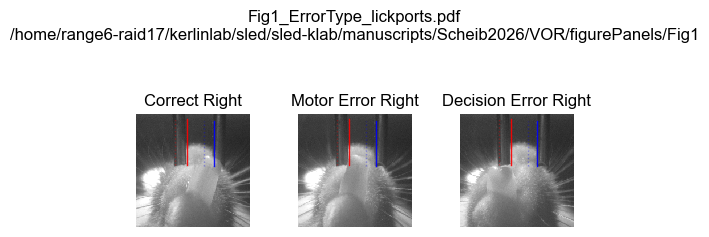

In [12]:
fontsize = 12
figName = 'Fig1_ErrorType_lickports.pdf'
bottCont = [0,200]

fig, axs = plt.subplots(1,3,tight_layout = True, figsize = [5,2])
imgs = [c1,c2,c3]
trackings = [dayRaw['side'], dayRaw['bottom']]
titles = ['Correct Right', 'Motor Error Right', 'Decision Error Right']
trials = [t1,t2,t3]
frames = [132,355,315]
for a, ax in enumerate(axs):
    ax.imshow(imgs[a][frames[a],:,:], vmin = bottCont[0],vmax=bottCont[1], cmap = 'Greys_r',interpolation='none')
    #ax.scatter(dayRaw['bottom'][trials[a]][0,frames[a]],dayRaw['bottom'][trials[a]][1,frames[a]], c = 'orange')
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    
    pColors = [(0,0,1),(1,0,0)]
    for s, side in enumerate(['right', 'left']):
        preLoc = anmData['port_locs']['pre_shift'][side][:2]/anmData['cameraCal']['bottomCam']
        print(f'{s} {side} {preLoc}')

        postLoc = anmData['port_locs']['post_shift'][side][:2]/anmData['cameraCal']['bottomCam']
        locs = [preLoc, postLoc]
        linestyles = [':','-']
        alphas = [0.3,0.9]
        for l, loc in enumerate(locs):
            ax.plot([loc[0]]*2, [-loc[1],-loc[1]+80], color = pColors[s], alpha = alphas[l], linestyle = linestyles[l], linewidth = 1)
        # ax.scatter(preLoc[0],-preLoc[1],facecolor = 'none', edgecolor = pColors[s])
        # ax.scatter(postLoc[0],-postLoc[1],c = pColors[s])
    ax.set_title(titles[a],fontsize=fontsize)
    # ax.set_ylim([100,300])
    # ax.set_xlim([200,0])
    ax.set_ylim([100,300])
    ax.set_xlim([0,200])
    ax.invert_xaxis()

jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


(1000, 300, 360)
(1000, 300, 240)
0 right [  62.999996 -208.      ]
1 left [ 110. -210.]


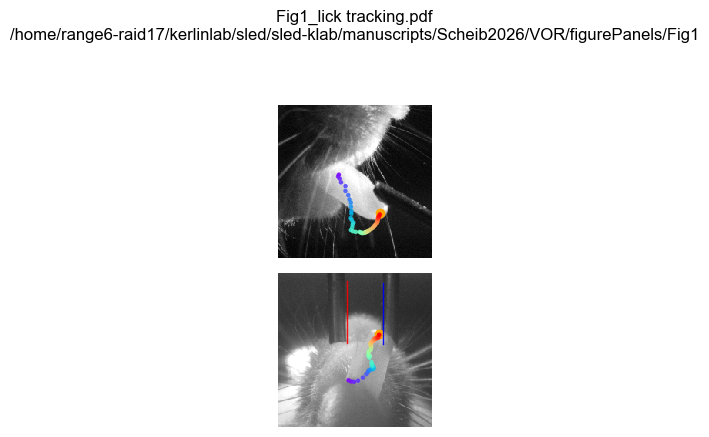

In [13]:
fig, axs = plt.subplots(2,1,tight_layout = True, figsize = [3,4])
imgs = [sideCam, bottomCam]
trackings = [dayRaw['side'], dayRaw['bottom']]
sideCont = [0,70]
bottCont = [0,200]
trials = [t1]*2
frames = [132]*2
backFrames = 45
for a, ax in enumerate(axs):
    print(imgs[a].shape)
    if a == 0:
        ax.imshow(imgs[a][frames[a],:,:], vmin = sideCont[0],vmax = sideCont[1], cmap = 'Greys_r',interpolation='none')
    else:
        ax.imshow(imgs[a][frames[a],:,:], vmin = bottCont[0],vmax = bottCont[1], cmap = 'Greys_r',interpolation='none')
        pColors = [(0,0,1),(1,0,0)]
        for s, side in enumerate(['right', 'left']):
            loc = anmData['port_locs']['post_shift'][side][:2]/anmData['cameraCal']['bottomCam']
            print(f'{s} {side} {loc}')
            ax.plot([loc[0]]*2, [-loc[1],-loc[1]+80], color = pColors[s], alpha = 0.9, linestyle = '-', linewidth = 1)

    
    ax.scatter(trackings[a][trials[a]][0,frames[a]],trackings[a][trials[a]][1,frames[a]], c = 'orange')
    ax.scatter(trackings[a][trials[a]][0,frames[a]-backFrames:frames[a]],trackings[a][trials[a]][1,frames[a]-backFrames:frames[a]],
               c = np.arange(45), cmap = 'rainbow', alpha = 0.8, s = 5)
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    if a == 1:
        ax.set_ylim([100,300])
        ax.set_xlim([200,0])
    else:
        ax.set_xlim([150,350])
        ax.set_ylim([300,100])

fontsize = 12
figName = 'Fig1_lick tracking.pdf'
jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


# 3D lick projections

In [14]:
anm = 'B00002213999'
anmData = masterData[anm]['behavior']
tracker = jsm.get_tracker(anmData)

Right 575
Left 409
Right 575
Left 409
Right 575
Left 409


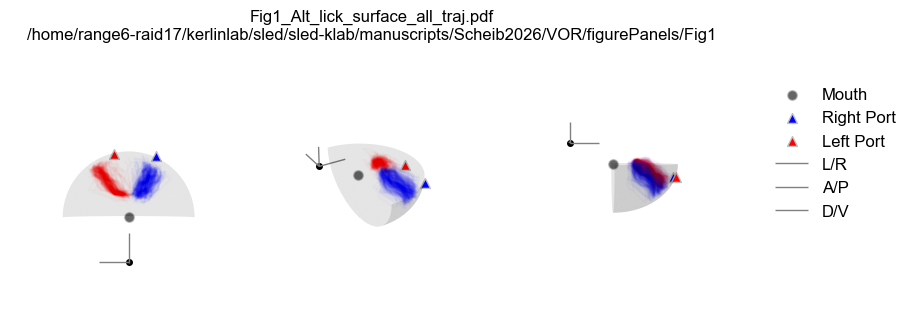

In [15]:
figName = 'Fig1_Alt_lick_surface_all_traj.pdf'

colors = [(0,0,1),(1,0,0), (0,0,0)]
labels = ['Right', 'Left']
# U, V, W components for 3 axes: [x_dir, y_dir, z_dir]
u_dirs = [2, 0, 0]
v_dirs = [0, 2, 0]
w_dirs = [0, 0, 2]
axshift_x = 0
axshift_y = 3
axshift_z = 2
exportSides = [0,1]
fontsize = 12
figsize = [10,3]
# fig = plt.figure(figsize = [15,5])
# ax = fig.add_subplot(111, projection = '3d')
fig = plt.figure(figsize = figsize)
ax1 = fig.add_subplot(131, projection = '3d')
ax2 = fig.add_subplot(132, projection = '3d')
ax3 = fig.add_subplot(133, projection = '3d')
plt.subplots_adjust(wspace=0.001, hspace=0.001)

mouth = anmData['mouth']
rp = anmData['port_locs']['pre_shift']['right']
lp = anmData['port_locs']['pre_shift']['left']
rad = jsm.identify_rad_3d(anmData, fraction = 1) #set a different rad with 'fraction'
radI = jsm.get_radIdxs_3d(anmData, licks, rad, count_if_noCross = False)
sm = tracker[:,0] < 0
drad = radI[sm]
dc = licks[sm,:,:]
dt = tracker[sm,:]

elevs = [90,30,0]
azims = [-90,150,0]
for a, ax in enumerate([ax1,ax2,ax3]):

    ax.view_init(elev = elevs[a], azim = azims[a])

    ax.scatter(mouth[0], mouth[1], mouth[2], color = (0,0,0), s = 50, edgecolor = (0.75,0.75,0.75), alpha = 0.6,label="Mouth",zorder=10)
    ax.scatter(rp[0], rp[1], rp[2], color = colors[0], s = 50, edgecolor = (0.75,0.75,0.75), marker = '^',label=labels[0]+" Port",zorder=10)
    ax.scatter(lp[0], lp[1], lp[2], color = colors[1], s = 50, edgecolor = (0.75,0.75,0.75), marker = '^',label=labels[1]+" Port",zorder=10)

    counts = np.zeros((len(exportSides)),dtype=int)
    for t in range(dt.shape[0]):
        for s, sideCode in enumerate(exportSides):
            if dt[t,2]==sideCode:
                if np.isfinite(drad[t]):
                    counts[s] +=1
                    i = int(drad[t])
                    ax.plot(dc[t,:i,0], dc[t,:i,1], dc[t,:i,2], alpha = 0.02, color = colors[s])
    for s, sideCode in enumerate(exportSides):
        print(f'{labels[s]} {counts[s]}')
    
    r = rad
    u = np.linspace(-np.pi, -2*np.pi, 100)
    v = np.linspace(-np.pi, -np.pi/2, 100)
    x = (r * np.outer(np.cos(u), np.sin(v)))
    y = (r * np.outer(np.sin(u), np.sin(v)))
    z = (r * np.outer(np.ones(np.size(u)), np.cos(v)))
    ax.plot_surface(x+mouth[0], y+mouth[1], z+mouth[2], color=(0,0,0), alpha=0.1)
    jsm.set_axes_equal(ax)
    ax.set_axis_off()
    ax.set_facecolor('none')


    
    # Plot the arrows
    # ax.quiver(X, Y, Z, U, V, W, ...)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[0], v_dirs[0], w_dirs[0], \
              color=(0.5,0.5,0.5), label='L/R',linewidth=1,arrow_length_ratio=0)
    # ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, -1*u_dirs[0], v_dirs[0], w_dirs[0], \
    #           color=colors[0], label='Right',linewidth=1,arrow_length_ratio=0)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[1], -1*v_dirs[1], w_dirs[1], \
              color=(0.5,0.5,0.5), label='A/P',linewidth=1,arrow_length_ratio=0)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[2], v_dirs[2], w_dirs[2], \
              color=(0.5,0.5,0.5), label='D/V',linewidth=1,arrow_length_ratio=0)
    
    ax.plot(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z,'.',color=(0,0,0),markersize=8)


    if a == 2:
        ax.legend(frameon=False,fontsize=fontsize,bbox_to_anchor=(1.01, 1), loc='upper left')


ax1.invert_xaxis()
ax1.invert_yaxis()
ax3.invert_yaxis()
jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


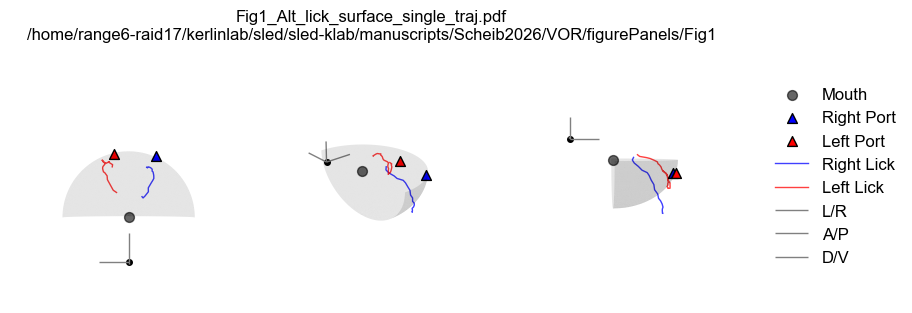

In [16]:
figName = 'Fig1_Alt_lick_surface_single_traj.pdf'
figsize = [10,3]

# fig = plt.figure(figsize = [15,5])
# ax = fig.add_subplot(111, projection = '3d')
fig = plt.figure(figsize = figsize)
ax1 = fig.add_subplot(131, projection = '3d')
ax2 = fig.add_subplot(132, projection = '3d')
ax3 = fig.add_subplot(133, projection = '3d')
plt.subplots_adjust(wspace=0.001, hspace=0.001)

mouth = anmData['mouth']
rp = anmData['port_locs']['pre_shift']['right']
lp = anmData['port_locs']['pre_shift']['left']
rad = jsm.identify_rad_3d(anmData, fraction = 1) #set a different rad with 'fraction'
radI = jsm.get_radIdxs_3d(anmData, licks, rad, count_if_noCross = False)
sm = tracker[:,0] < 0
drad = radI[sm]
dc = licks[sm,:,:]
dt = tracker[sm,:]

cTimes = jsm.get_cTimes2(anmData)[sm]
cF = np.where(np.min(abs(dc[:,:,3]-cTimes[:,None]), axis = 1))[0]
rTs = np.where(tracker[sm,2]==0)[0]
rT = rTs[10]#10
lTs = np.where(tracker[sm,2]==1)[0]
lT = lTs[10]#10

elevs = [90,25,0]
azims = [-90,140,0]
for a, ax in enumerate([ax1,ax2,ax3]):

    ax.view_init(elev = elevs[a], azim = azims[a])
    
    ax.scatter(mouth[0], mouth[1], mouth[2], color = (0,0,0), s = 50, edgecolor = (0,0,0), alpha = 0.6, label = 'Mouth')
    ax.scatter(rp[0], rp[1], rp[2], color = colors[0], s = 50, edgecolor = (0,0,0), marker = '^',label=str(labels[0])+" Port")
    ax.scatter(lp[0], lp[1], lp[2], color = colors[1], s = 50, edgecolor = (0,0,0), marker = '^',label=str(labels[1])+" Port")

    rI = int(drad[rT])-1
    rC = int(cF[rT])-1
    ax.plot(dc[rT,:rC,0], dc[rT,:rC,1], dc[rT,:rC,2], alpha = 0.75, color = colors[0], linestyle = '-', linewidth = 1,label='Right Lick')
    lI = int(drad[lT])-1
    lC = int(cF[lT])-1
    ax.plot(dc[lT,:lC,0], dc[lT,:lC,1], dc[lT,:lC,2], alpha = .75, color = colors[1], linestyle = '-', linewidth = 1,label='Left Lick')
    r = rad
    u = np.linspace(-np.pi, -2*np.pi, 100)
    v = np.linspace(-np.pi, -np.pi/2, 100)
    x = (r * np.outer(np.cos(u), np.sin(v)))
    y = (r * np.outer(np.sin(u), np.sin(v)))
    z = (r * np.outer(np.ones(np.size(u)), np.cos(v)))
    ax.plot_surface(x+mouth[0], y+mouth[1], z+mouth[2], color=(0,0,0), alpha=0.1)
    jsm.set_axes_equal(ax)
        
    # Plot the arrows
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[0], v_dirs[0], w_dirs[0], \
              color=(0.5,0.5,0.5), label='L/R',linewidth=1,arrow_length_ratio=0)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[1], -1*v_dirs[1], w_dirs[1], \
              color=(0.5,0.5,0.5), label='A/P',linewidth=1,arrow_length_ratio=0)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[2], v_dirs[2], w_dirs[2], \
              color=(0.5,0.5,0.5), label='D/V',linewidth=1,arrow_length_ratio=0)
    
    ax.plot(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z,'.',color=(0,0,0),markersize=8)

    ax.set_axis_off()
    ax.set_facecolor('none')
    if a == 2:
        ax.legend(frameon=False,fontsize=fontsize,bbox_to_anchor=(1.01, 1), loc='upper left')

ax1.invert_xaxis()
ax1.invert_yaxis()
ax3.invert_yaxis()
jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


# Example animal lick distributions

Right n = 576
Left n = 444


/tmp/ipykernel_982604/1462444367.py:46: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(azi[mask]+azi_shift, ele[mask], s=ms, c=sColors[t], alpha=0.1,label=labels[t],edgecolor=None)


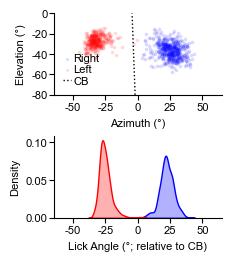

In [17]:
%matplotlib inline
figName = 'Fig1_lick_locations_pre.pdf'

fontsize = 8
ms = 3
figSize = [2.2,2.5]
xlim1 = [-155,-25]
xlim1 = [-65,65]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.1]
ylim2 = [0,0.4]
yticks1 = [0,-20,-40,-60,-80]
#titles = ['Pre-Shift', 'Post-Shift']
sColors = [(0,0,1),(1,0,0)]
labels = ['Right', 'Left']
azi_shift = 0#90
histMeth = 'kde'#'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]
loc='lower left'
sm = tracker[:,0] < 0
rTs = np.where(tracker[sm,2]==0)[0]
rT = rTs[10]#10
lTs = np.where(tracker[sm,2]==1)[0]
lT = lTs[10]#10
azi,ele = jsm.get_aziEle(anmData, licks)
azi = azi+90
lickAngles = jsm.get_lickAngle(azi, ele, CB)

fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

w = CB.coef_[0]
C = CB.intercept_[0]
A, B = w[0], w[1]

exampleTrials = [rT, lT]
xOffsets = [-10,-20]
for t in range(2):
    mask = np.logical_and(tracker[:,0]<0, tracker[:,2]==t)
    print(f'{labels[t]} n = {np.sum(mask==True)}')
    ax.scatter(azi[mask]+azi_shift, ele[mask], s=ms, c=sColors[t], alpha=0.1,label=labels[t],edgecolor=None)
ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.set_yticks(yticks1)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

ax = axs[1]

if histMeth == 'kde':
    sns.kdeplot(lickAngles[np.logical_and(tracker[:,0]<0, tracker[:,2]==0)]*-1, alpha = 0.3, color = (0,0,1), ax = axs[1], fill = True)
    sns.kdeplot(lickAngles[np.logical_and(tracker[:,0]<0, tracker[:,2]==1)]*-1, alpha = 0.3, color = (1,0,0), ax = axs[1], fill = True)
elif histMeth == 'pdf':
    tempData = lickAngles[np.logical_and(tracker[:,0]<0, tracker[:,2]==0)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = (0,0,1), alpha = 0.3,edgecolor = 'none')
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (0,0,1), lw = 1,ls='-',label = 'Pre-Shift R')

    tempData = lickAngles[np.logical_and(tracker[:,0]<0, tracker[:,2]==1)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = (1,0,0), alpha = 0.3,edgecolor = 'none')
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (1,0,0), lw = 1,ls='-',label = 'Pre-Shift L')


    ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
ax.set_ylabel('Density',fontsize=fontsize)

ax.set_xlim(xlim2)
ax.set_xticks(xticks2)


for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    # ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #

plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


/tmp/ipykernel_982604/682755702.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(azi[mask]+azi_shift, ele[mask], s=5, c=sColors[t], alpha=0.1)
/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:7065: RuntimeWarning: divide by zero encountered in log10
  hist_log10 = np.log10(hist_log10)
/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/scipy/stats/_stats_py.py:267: RuntimeWarning: invalid value encountered in log
  log_a = np.log(a)


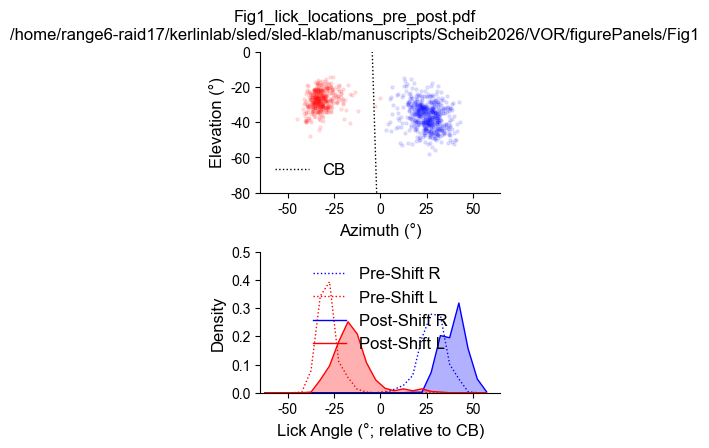

In [18]:
figName = 'Fig1_lick_locations_pre_post.pdf'

fontsize = 12
figSize = [3,4]
xlim1 = [-65,65]
xlim1 = [-65,65]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.1]
ylim2 = [0,0.5]
titles = ['Pre-Shift', 'Post-Shift']
sColors = [(0,0,1),(1,0,0)]
labels = ['Right', 'Left']
azi_shift = 0
histMeth = 'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]

sm = tracker[:,0] < 0
postMask = jsm.get_behaviorShiftMask(tracker,'post')
rTs = np.where(tracker[sm,2]==0)[0]
rT = rTs[10]
lTs = np.where(tracker[sm,2]==1)[0]
lT = lTs[10]

fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

w = CB.coef_[0]
b = CB.intercept_[0]

exampleTrials = [rT, lT]
xOffsets = [0,-10]
for t in range(2):
    mask = np.logical_and(tracker[:,0]<0, tracker[:,2]==t)
    ax.scatter(azi[mask]+azi_shift, ele[mask], s=5, c=sColors[t], alpha=0.1)
ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
ax.legend(frameon=False, loc = 'lower left',fontsize=fontsize)

ax = axs[1]

if histMeth == 'kde':
    sns.kdeplot(cDists[np.logical_and(tracker[:,0]<0, tracker[:,2]==0)]*-1, alpha = 0.3, color = (0,0,1), ax = axs[1], fill = True)
    sns.kdeplot(cDists[np.logical_and(tracker[:,0]<0, tracker[:,2]==1)]*-1, alpha = 0.3, color = (1,0,0), ax = axs[1], fill = True)
    sns.kdeplot(cDists[np.logical_and(postMask, tracker[:,2]==0)]*-1, alpha = 0.8, color = (0,0,1), ax = axs[1], fill = False)
    sns.kdeplot(cDists[np.logical_and(postMask, tracker[:,2]==1)]*-1, alpha = 0.8, color = (1,0,0), ax = axs[1], fill = False)
elif histMeth == 'pdf':
    tempData = cDists[np.logical_and(tracker[:,0]<0, tracker[:,2]==0)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (0,0,1), lw = 1,ls=':',label = 'Pre-Shift R')

    tempData = cDists[np.logical_and(tracker[:,0]<0, tracker[:,2]==1)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (1,0,0), lw = 1,ls=':',label = 'Pre-Shift L')

    tempData = cDists[np.logical_and(postMask, tracker[:,2]==0)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = (0,0,1), alpha = 0.3,edgecolor = 'none')
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (0,0,1), lw = 1,label = 'Post-Shift R')

    tempData = cDists[np.logical_and(postMask, tracker[:,2]==1)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = (1,0,0), alpha = 0.3,edgecolor = 'none')
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (1,0,0), lw = 1,label = 'Post-Shift L')

    ax.legend(frameon=False, loc = 'upper center',fontsize=fontsize)
ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
ax.set_ylabel('Density',fontsize=fontsize)
ax.set_xticks(xticks2)

ax.set_ylim(ylim2)
ax.set_xlim(xlim2)


for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #


jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


/tmp/ipykernel_982604/2847977716.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(azi[mask],ele[mask], s = 5, c = sColors[t], alpha = 0.1,label = labels[t])
/tmp/ipykernel_982604/2847977716.py:32: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(azi[mask], ele[mask], s = 20, c = errColors[m], alpha = 0.4, marker = 'x',label = labels[t]+" Error")


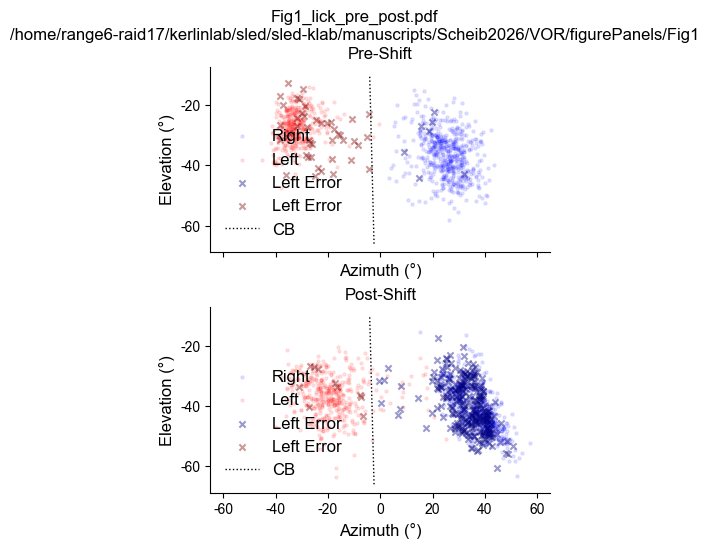

In [19]:
figName = 'Fig1_lick_pre_post.pdf'
fontsize = 12
figSize = [4,5]
sColors = [(0,0,1),(1,0,0)]
errColors = [(0,0,0.5),(0.5,0,0)]
labels = ['Right', 'Left']
xlim = [-65,65]
#############################
fig, axs = jsm.clean_subplots(2,1,figsize=figSize,sharey=True,sharex=True,constrained_layout=True)
titles = ['Pre-Shift', 'Post-Shift']
for a, ax in enumerate(axs):
    for t in range(2):
        if a==0:
            mask = np.logical_and(tracker[:,0]<0, tracker[:,2]==t)
        else:
            mask = np.logical_and(tracker[:,0]==0, tracker[:,1]>100)
            mask = np.logical_or(mask, tracker[:,0]>0)
            mask = np.logical_and(mask, tracker[:,2]==t)
        ax.scatter(azi[mask],ele[mask], s = 5, c = sColors[t], alpha = 0.1,label = labels[t])
    ax.set_title(titles[a],fontsize=fontsize)
    ax.set_ylabel('Elevation (°)',fontsize=fontsize)
    ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
for a, ax in enumerate(axs):
    if a == 0:
        mask1 = np.logical_and(tracker[:,0]<0, tracker[:,2]==5)
    else:
        mask1 = np.logical_and(tracker[:,0]==0, tracker[:,1]>100)
        mask1 = np.logical_or(mask1, tracker[:,0]>0)
        mask1 = np.logical_and(mask1, tracker[:,2]==5)
    for m, errType in enumerate([me,de]):
        mask = np.logical_and(mask1, errType)
        ax.scatter(azi[mask], ele[mask], s = 20, c = errColors[m], alpha = 0.4, marker = 'x',label = labels[t]+" Error")
for ax in axs:
    ax.spines[['top','right']].set_visible(False)

w = CB.coef_[0]
b = CB.intercept_[0]
m = -w[0] / w[1]
c = -b / w[1]

xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
yrng = m * xrng + c

ymin, ymax = ax.get_ylim()
x1 = (ymin - c) / m
x2 = (ymax - c) / m
for ax in axs:
    ax.plot([x1, x2], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label='CB')

for a, ax in enumerate(axs):
    ax.legend(frameon=False, loc = 'lower left',fontsize=fontsize)
    ax.set_xlim(xlim)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #

jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

/tmp/ipykernel_982604/911959391.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])


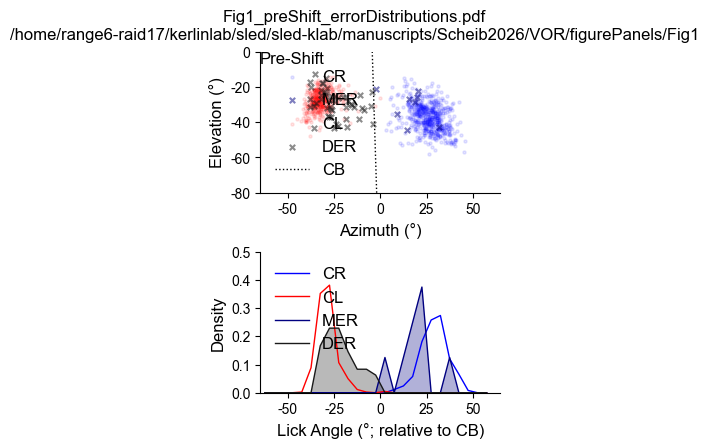

In [20]:
figName = 'Fig1_preShift_errorDistributions.pdf'

fontsize = 12
figSize = [3,4]
# xlim1 = [-155,-25]
xlim1 = [-65,65]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.5]
#sColors = [(0,0,1),(1,0,0)]
sColors = [(0,0,1), (0,0,0.5), (1,0,0), (0.1,0.1,0.1)]
labels = ['CR', 'MER', 'CL', 'DER']
azi_shift = 0
histMeth = 'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]

linewidth = 1
preMask = jsm.get_behaviorShiftMask(tracker, 'pre')

fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

w = CB.coef_[0]
C = CB.intercept_[0]
A, B = w[0], w[1]

xOffsets = [0,-10]
meMask = np.logical_and(np.logical_and(preMask, me), tracker[:,2]==5)
deMask = np.logical_and(np.logical_and(preMask, de), tracker[:,2]==5)
clMask = np.logical_and(preMask, tracker[:,2]==1)
crMask = np.logical_and(preMask, tracker[:,2]==0)
masks = [crMask, meMask, clMask, deMask]
markers = ['o','x','o','x']
alphas = [.1,.5,.1,.5]
sizes = [5,15,5,15]
handels = []
for t in range(4):
    mask = masks[t]
    sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])
    handels.append(sct)
ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    LDALine, = ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
    
ax.text(xlim1[0],ylim1[1],'Pre-Shift',color = (0,0,0),fontsize=fontsize,ha='left',va='top')
ax.legend(loc='lower left', frameon=False,fontsize=fontsize)

ax = axs[1]
masks = [crMask, clMask, meMask, deMask]
labels = ['CR','CL','MER','DER']
linestyles = ['-','-','-','-']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.9,.9,.3,.3]
fills = [False,False,True,True]
for m, mask in enumerate(masks):
    if histMeth == 'kde':
        sns.kdeplot(cDists[mask]*-1, alpha = alphas[m], color = colors[m], ax = axs[1], fill = fills[m], lw = linewidth)
        ax.plot(-100,-100,'-',lw=linewidth,color=colors[m],label=labels[m])
    elif histMeth == 'pdf':
        tempStat = jsm.summary_stats(cDists[mask]*-1,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
            calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
            calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
            save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
        if fills[m]:
            ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = colors[m], alpha = alphas[m],edgecolor = 'none')

        ax.plot(tempStat['binCenters'],tempStat['pdf'],  color = colors[m], lw = linewidth,ls=linestyles[m],label = labels[m])

ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
ax.set_ylabel('Density',fontsize=fontsize)
ax.set_xticks(xticks2)
ax.legend(frameon=False,fontsize=fontsize)
ax.set_ylim(ylim2)
ax.set_xlim(xlim2)
for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #


jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


/tmp/ipykernel_982604/2575712067.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])


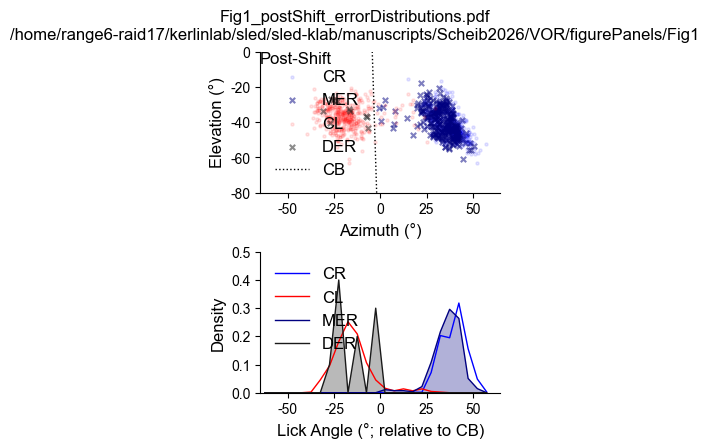

In [21]:
figName = 'Fig1_postShift_errorDistributions.pdf'

fontsize = 12
figSize = [3,4]
xlim1 = [-155,-25]
xlim1 = [-65,65]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.5]
#sColors = [(0,0,1),(1,0,0)]
sColors = [(0,0,1), (0,0,0.5), (1,0,0), (0.1,0.1,0.1)]
labels = ['CR', 'MER', 'CL', 'DER']
azi_shift = 0
histMeth = 'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]

linewidth = 1
postMask = jsm.get_behaviorShiftMask(tracker, 'post')

fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

w = CB.coef_[0]
C = CB.intercept_[0]
A, B = w[0], w[1]

xOffsets = [0,-10]
meMask = np.logical_and(np.logical_and(postMask, me), tracker[:,2]==5)
deMask = np.logical_and(np.logical_and(postMask, de), tracker[:,2]==5)
clMask = np.logical_and(postMask, tracker[:,2]==1)
crMask = np.logical_and(postMask, tracker[:,2]==0)
masks = [crMask, meMask, clMask, deMask]
markers = ['o','x','o','x']
alphas = [.1,.5,.1,.5]
sizes = [5,15,5,15]
handels = []
for t in range(4):
    mask = masks[t]
    sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])
    handels.append(sct)
ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    LDALine, = ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
    
ax.text(xlim1[0],ylim1[1],'Post-Shift',color = (0,0,0),fontsize=fontsize,ha='left',va='top')
ax.legend(loc='lower left', frameon=False,fontsize=fontsize)

ax = axs[1]
masks = [crMask, clMask, meMask, deMask]
labels = ['CR','CL','MER','DER']
linestyles = ['-','-','-','-']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.9,.9,.3,.3]
fills = [False,False,True,True]
for m, mask in enumerate(masks):
    if histMeth == 'kde':
        sns.kdeplot(cDists[mask]*-1, alpha = alphas[m], color = colors[m], ax = axs[1], fill = fills[m], lw = linewidth)
        ax.plot(-100,-100,'-',lw=linewidth,color=colors[m],label=labels[m])
    elif histMeth == 'pdf':
        tempStat = jsm.summary_stats(cDists[mask]*-1,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
            calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
            calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
            save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
        if fills[m]:
            ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = colors[m], alpha = alphas[m],edgecolor = 'none')

        ax.plot(tempStat['binCenters'],tempStat['pdf'],  color = colors[m], lw = linewidth,ls=linestyles[m],label = labels[m])

ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
ax.set_ylabel('Density',fontsize=fontsize)
ax.set_xticks(xticks2)
ax.legend(frameon=False,fontsize=fontsize)
ax.set_ylim(ylim2)
ax.set_xlim(xlim2)
for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #

jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


CR 641
CL 458
MER 277
DER 10


/tmp/ipykernel_982604/2870220377.py:51: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t],edgecolor=None)
/tmp/ipykernel_982604/2870220377.py:81: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[

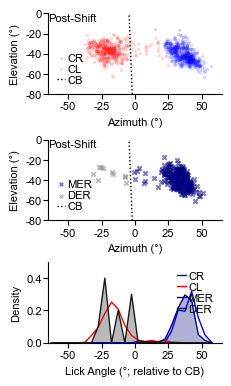

In [22]:
figName = 'Fig1_postShift_errorDistributions_splitError.pdf'

fontsize = 8
ms1 = 3
ms2 = 5
figSize = [2.2,3.75]
xlim1 = [-155,-25]
xlim1 = [-65,65]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
yticks1 = [0,-20,-40,-60,-80]
ylim1 = [-80,0]
ylim2 = [0,0.5]
#sColors = [(0,0,1),(1,0,0)]
sColors = [(0,0,1), (0,0,0.5), (1,0,0), (0.5,0.5,0.5)]
labels = ['CR', 'MER', 'CL', 'DER']
azi_shift = 0
histMeth = 'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]
loc='lower left'
linewidth = 1
postMask = jsm.get_behaviorShiftMask(tracker, 'post')

fig, axs = jsm.clean_subplots(3,1,figsize=figSize,constrained_layout=True)

w = CB.coef_[0]
C = CB.intercept_[0]
A, B = w[0], w[1]

xOffsets = [0,-10]
meMask = np.logical_and(np.logical_and(postMask, me), tracker[:,2]==5)
deMask = np.logical_and(np.logical_and(postMask, de), tracker[:,2]==5)
clMask = np.logical_and(postMask, tracker[:,2]==1)
crMask = np.logical_and(postMask, tracker[:,2]==0)
masks = [crMask, meMask, clMask, deMask]
markers = ['o','x','o','x']
alphas = [.1,.5,.1,.5]
sizes = [3,10,3,10]
handels = []

ax = axs[0]
indicies = [0,2]
for t in indicies:
    mask = masks[t]
    if markers[t] == 'x':
        sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])
    else:
        sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t],edgecolor=None)        
    handels.append(sct)
    print(f'{labels[t]} {np.sum(mask==True)}')
ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.set_yticks(yticks1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    LDALine, = ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
    
ax.text(xlim1[0],ylim1[1],'Post-Shift',color = (0,0,0),fontsize=fontsize,ha='left',va='top')
ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

ax = axs[1]
indicies = [1,3]
for t in indicies:
    mask = masks[t]
    if markers[t] == 'x':
        sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])
    else:
        sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t],edgecolor=None)
    handels.append(sct)
    print(f'{labels[t]} {np.sum(mask==True)}')

ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.set_yticks(yticks1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    LDALine, = ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
    
ax.text(xlim1[0],ylim1[1],'Post-Shift',color = (0,0,0),fontsize=fontsize,ha='left',va='top')
ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 


ax = axs[2]
loc='upper right'
masks = [crMask, clMask, meMask, deMask]
labels = ['CR','CL','MER','DER']
linestyles = ['-','-','-','-']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.9,.9,.3,.3]
fills = [False,False,True,True]
for m, mask in enumerate(masks):
    if histMeth == 'kde':
        sns.kdeplot(cDists[mask]*-1, alpha = alphas[m], color = colors[m], ax = axs[1], fill = fills[m], lw = linewidth)
        ax.plot(-100,-100,'-',lw=linewidth,color=colors[m],label=labels[m])
    elif histMeth == 'pdf':
        tempStat = jsm.summary_stats(cDists[mask]*-1,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
            calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
            calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
            save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
        if fills[m]:
            ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = colors[m], alpha = alphas[m],edgecolor = 'none')

        ax.plot(tempStat['binCenters'],tempStat['pdf'],  color = colors[m], lw = linewidth,ls=linestyles[m],label = labels[m])


ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
ax.set_ylabel('Density',fontsize=fontsize)
ax.set_xticks(xticks2)
ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
ax.set_ylim(ylim2)
ax.set_xlim(xlim2)
for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    # ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #

plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


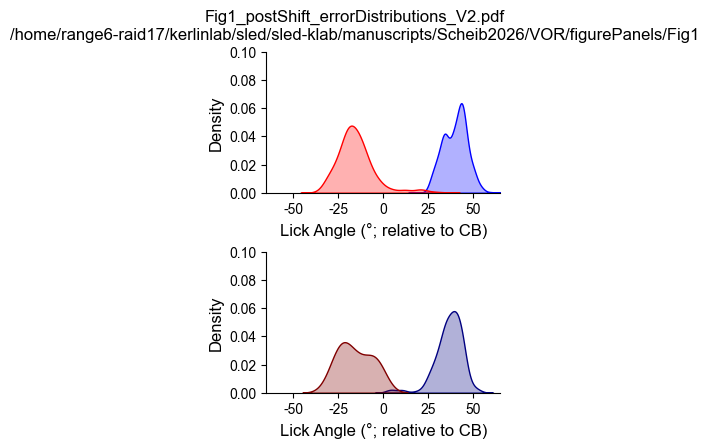

In [23]:
figName = 'Fig1_postShift_errorDistributions_V2.pdf'

fontsize = 12
figSize = [3,4]
xlim1 = [-155,-25]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.1]
titles = ['Pre-Shift', 'Post-Shift']
sColors = [[(0,0,1), (1,0,0)],[(0,0,0.5),(0.5,0,0)]]
labels = [['CR','CL'],['MER','DER']]

postMask = jsm.get_behaviorShiftMask(tracker, 'post')
fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

meMask = np.logical_and(np.logical_and(postMask, me), tracker[:,2]==5)
deMask = np.logical_and(np.logical_and(postMask, de), tracker[:,2]==5)
clMask = np.logical_and(postMask, tracker[:,2]==1)
crMask = np.logical_and(postMask, tracker[:,2]==0)
masks = [[crMask, clMask],[meMask, deMask]]

for i in range(2):
    ax = axs[i]
    for m in range(2):
        sns.kdeplot(cDists[masks[i][m]]*-1, alpha = .3, color = sColors[i][m], fill = True, ax = ax)

    ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
    ax.set_ylabel('Density',fontsize=fontsize)
    ax.set_xticks(xticks2)
    
    ax.set_ylim(ylim2)
    ax.set_xlim(xlim2)
for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #

jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


Right 575
Left 409
Right 575
Left 409
Right 575
Left 409


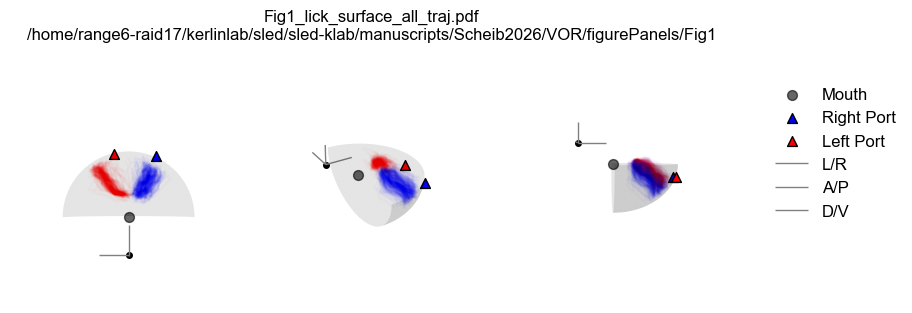

In [24]:
figName = 'Fig1_lick_surface_all_traj.pdf'

colors = [(0,0,1),(1,0,0), (0,0,0)]
labels = ['Right', 'Left']
# U, V, W components for 3 axes: [x_dir, y_dir, z_dir]
u_dirs = [2, 0, 0]
v_dirs = [0, 2, 0]
w_dirs = [0, 0, 2]
axshift_x = 0
axshift_y = 2.5
axshift_z = 2
exportSides = [0,1]
fontsize = 12
figsize = [10,3]
fig = plt.figure(figsize = figsize)
ax1 = fig.add_subplot(131, projection = '3d')
ax2 = fig.add_subplot(132, projection = '3d')
ax3 = fig.add_subplot(133, projection = '3d')
plt.subplots_adjust(wspace=0.001, hspace=0.001)

mouth = anmData['mouth']
rp = anmData['port_locs']['pre_shift']['right']
lp = anmData['port_locs']['pre_shift']['left']
rad = jsm.identify_rad_3d(anmData, fraction = 1) #set a different rad with 'fraction'
radI = jsm.get_radIdxs_3d(anmData, licks, rad, count_if_noCross = False)
sm = tracker[:,0] < 0
drad = radI[sm]
dc = licks[sm,:,:]
dt = tracker[sm,:]

elevs = [90,30,0]
azims = [-90,150,0]
for a, ax in enumerate([ax1,ax2,ax3]):

    ax.view_init(elev = elevs[a], azim = azims[a])

    ax.scatter(mouth[0], mouth[1], mouth[2], color = (0,0,0), s = 50, edgecolor = (0,0,0), alpha = 0.6,label="Mouth")
    ax.scatter(rp[0], rp[1], rp[2], color = colors[0], s = 50, edgecolor = (0,0,0), marker = '^',label=labels[0]+" Port")
    ax.scatter(lp[0], lp[1], lp[2], color = colors[1], s = 50, edgecolor = (0,0,0), marker = '^',label=labels[1]+" Port")

    counts = np.zeros((len(exportSides)),dtype=int)
    for t in range(dt.shape[0]):
        for s, sideCode in enumerate(exportSides):
            if dt[t,2]==sideCode:
                if np.isfinite(drad[t]):
                    counts[s] +=1
                    i = int(drad[t])
                    ax.plot(dc[t,:i,0], dc[t,:i,1], dc[t,:i,2], alpha = 0.02, color = colors[s])
    for s, sideCode in enumerate(exportSides):
        print(f'{labels[s]} {counts[s]}')
    
    r = rad
    u = np.linspace(-np.pi, -2*np.pi, 100)
    v = np.linspace(-np.pi, -np.pi/2, 100)
    x = (r * np.outer(np.cos(u), np.sin(v)))
    y = (r * np.outer(np.sin(u), np.sin(v)))
    z = (r * np.outer(np.ones(np.size(u)), np.cos(v)))
    ax.plot_surface(x+mouth[0], y+mouth[1], z+mouth[2], color=(0,0,0), alpha=0.1)
    jsm.set_axes_equal(ax)
    ax.set_axis_off()
    ax.set_facecolor('none')

    # Plot the arrows
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[0], v_dirs[0], w_dirs[0], \
              color=(0.5,0.5,0.5), label='L/R',linewidth=1,arrow_length_ratio=0)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[1], -1*v_dirs[1], w_dirs[1], \
              color=(0.5,0.5,0.5), label='A/P',linewidth=1,arrow_length_ratio=0)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[2], v_dirs[2], w_dirs[2], \
              color=(0.5,0.5,0.5), label='D/V',linewidth=1,arrow_length_ratio=0)
    
    ax.plot(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z,'.',color=(0,0,0),markersize=8)

    if a == 2:
        ax.legend(frameon=False,fontsize=fontsize,bbox_to_anchor=(1.01, 1), loc='upper left')

ax1.invert_xaxis()
ax1.invert_yaxis()
ax3.invert_yaxis()
jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

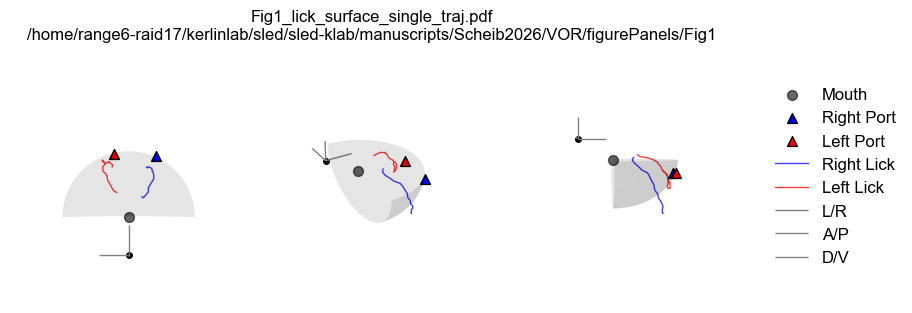

In [25]:
figName = 'Fig1_lick_surface_single_traj.pdf'
figsize = [10,3]

fig = plt.figure(figsize = figsize)
ax1 = fig.add_subplot(131, projection = '3d')
ax2 = fig.add_subplot(132, projection = '3d')
ax3 = fig.add_subplot(133, projection = '3d')
plt.subplots_adjust(wspace=0.001, hspace=0.001)

mouth = anmData['mouth']
rp = anmData['port_locs']['pre_shift']['right']
lp = anmData['port_locs']['pre_shift']['left']
rad = jsm.identify_rad_3d(anmData, fraction = 1) #set a different rad with 'fraction'
radI = jsm.get_radIdxs_3d(anmData, licks, rad, count_if_noCross = False)
sm = tracker[:,0] < 0
drad = radI[sm]
dc = licks[sm,:,:]
dt = tracker[sm,:]

cTimes = jsm.get_cTimes2(anmData)[sm]
cF = np.where(np.min(abs(dc[:,:,3]-cTimes[:,None]), axis = 1))[0]

for a, ax in enumerate([ax1,ax2,ax3]):

    ax.view_init(elev = elevs[a], azim = azims[a])
    
    ax.scatter(mouth[0], mouth[1], mouth[2], color = (0,0,0), s = 50, edgecolor = (0,0,0), alpha = 0.6, label = 'Mouth')
    ax.scatter(rp[0], rp[1], rp[2], color = colors[0], s = 50, edgecolor = (0,0,0), marker = '^',label=labels[0]+" Port")
    ax.scatter(lp[0], lp[1], lp[2], color = colors[1], s = 50, edgecolor = (0,0,0), marker = '^',label=labels[1]+" Port")

    rI = int(drad[rT])-1
    rC = int(cF[rT])-1
    ax.plot(dc[rT,:rC,0], dc[rT,:rC,1], dc[rT,:rC,2], alpha = 0.75, color = colors[0], linestyle = '-', linewidth = 1,label='Right Lick')
    lI = int(drad[lT])-1
    lC = int(cF[lT])-1
    ax.plot(dc[lT,:lC,0], dc[lT,:lC,1], dc[lT,:lC,2], alpha = .75, color = colors[1], linestyle = '-', linewidth = 1,label='Left Lick')

    r = rad
    u = np.linspace(-np.pi, -2*np.pi, 100)
    v = np.linspace(-np.pi, -np.pi/2, 100)
    x = (r * np.outer(np.cos(u), np.sin(v)))
    y = (r * np.outer(np.sin(u), np.sin(v)))
    z = (r * np.outer(np.ones(np.size(u)), np.cos(v)))
    ax.plot_surface(x+mouth[0], y+mouth[1], z+mouth[2], color=(0,0,0), alpha=0.1)
    jsm.set_axes_equal(ax)
        
    # Plot the arrows
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[0], v_dirs[0], w_dirs[0], \
              color=(0.5,0.5,0.5), label='L/R',linewidth=1,arrow_length_ratio=0)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[1], -1*v_dirs[1], w_dirs[1], \
              color=(0.5,0.5,0.5), label='A/P',linewidth=1,arrow_length_ratio=0)
    ax.quiver(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z, u_dirs[2], v_dirs[2], w_dirs[2], \
              color=(0.5,0.5,0.5), label='D/V',linewidth=1,arrow_length_ratio=0)
    
    ax.plot(mouth[0]+axshift_x, mouth[1]+axshift_y, mouth[2]+axshift_z,'.',color=(0,0,0),markersize=8)

    ax.set_axis_off()
    ax.set_facecolor('none')
    if a == 2:
        ax.legend(frameon=False,fontsize=fontsize,bbox_to_anchor=(1.01, 1), loc='upper left')

ax1.invert_xaxis()
ax1.invert_yaxis()
ax3.invert_yaxis()
jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


# Alternate example animal lick distributions

In [26]:
anm = 'B00002213889'
anmData = masterData[anm]['behavior']
licks = jsm.get_contacts(anmData['trajs'])
cTimes = jsm.get_cTimes2(anmData)
tracker = jsm.get_tracker(anmData)
azi,ele = jsm.get_aziEle(anmData, licks)
azi = azi+90
cDists = jsm.get_relDistances(azi, ele, tracker)
lickAngles = jsm.get_lickAngle(azi, ele, CB)

me, de, CB = jsm.get_errors_LDA(azi, ele, tracker, returnLDA = True)
recDays = np.hstack([anmData['mats'][m]['Info']['SessionDate'] for m in range(len(anmData['mats']))])
uniqueDays = np.unique(tracker[:,0])
for i in range(len(recDays)):
    print(uniqueDays[i], recDays[i])

-4 16-Sep-2023
-3 17-Sep-2023
-2 18-Sep-2023
-1 19-Sep-2023
0 20-Sep-2023
1 21-Sep-2023
2 22-Sep-2023


In [27]:
dayIdx = 4
dayPath = f'{anmPath}/{days[dayIdx]}/run1'
# files = os.listdir(dayPath)
# camIDs = tt.extract_camIDs(files)
print(dayPath)
dayRaw = anmData['raw'][dayIdx]

/home/range6-raid17/kerlinlab/raw/behavior/B00002213999/240324/run1


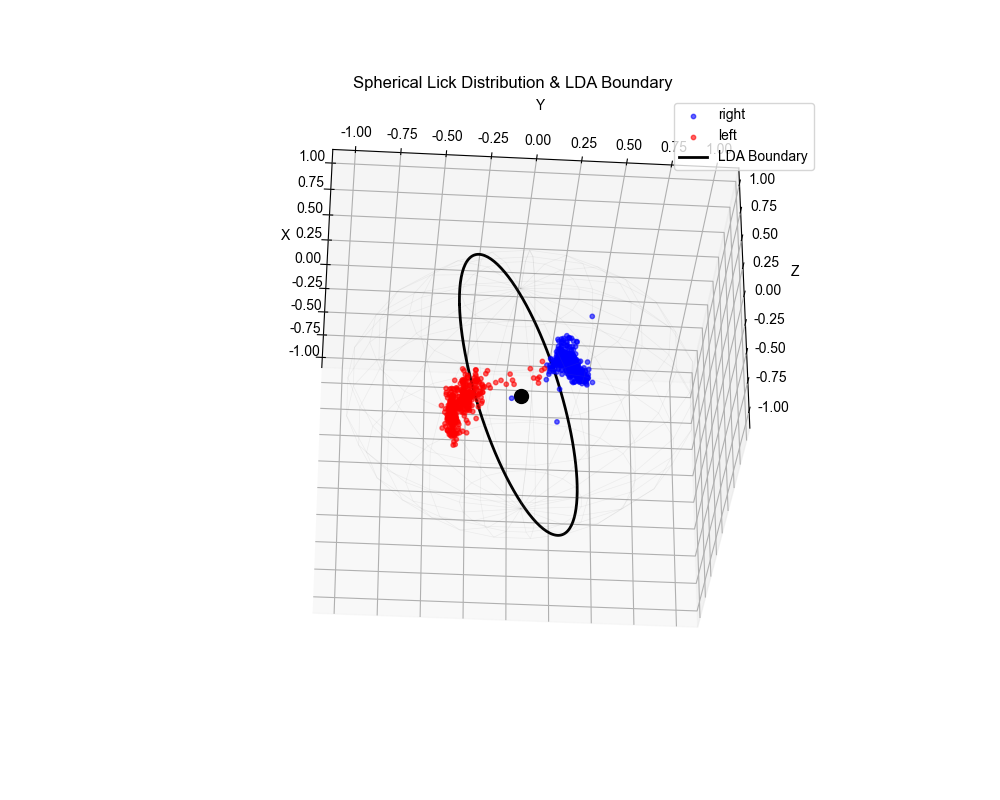

In [28]:
%matplotlib widget
# Usage:
preMask = allAnmParams[anm]['shiftMask']['pre']
jsm.plot_lick_boundary_3d(azi[preMask], ele[preMask], CB, tracker[preMask,:])

Right n = 539
Left n = 347


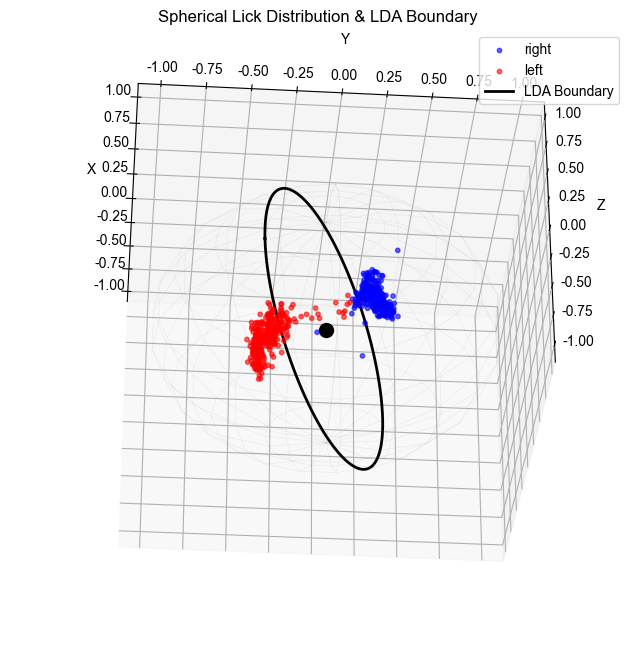

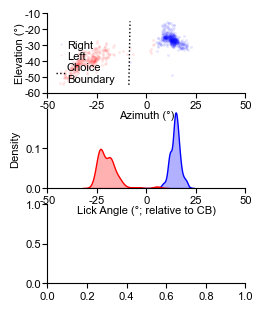

In [29]:
%matplotlib inline
figName = 'Fig1_Alt_lick_locations_pre.pdf'
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.2
)

fontsize = 8
ms = 4
figSize = [2.2,3]
xlim1 = [-155,-25]
xlim1 = [-50,50]
xlim2 = [-50,50]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
ylim2 = [0,0.1]
ylim2 = [0,0.4]
yticks1 = [-10,-20,-30,-40,-50,-60]
ylim1 = [-60,-10]
#titles = ['Pre-Shift', 'Post-Shift']
sColors = [(0,0,1),(1,0,0)]
labels = ['Right', 'Left']
azi_shift = 0#90
histMeth = 'kde'#'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]
loc='lower left'
sm = tracker[:,0] < 0
rTs = np.where(tracker[sm,2]==0)[0]
rT = rTs[10]#10
lTs = np.where(tracker[sm,2]==1)[0]
lT = lTs[10]#10

fig, axs = jsm.clean_subplots(3,1,figsize=figSize,gridspec_kw=gridspec_kw)
axs = axs.flatten()

w = CB.coef_[0]
C = CB.intercept_[0]
A, B = w[0], w[1]

exampleTrials = [rT, lT]
xOffsets = [-10,-20]
ax = axs[0]
for t in range(2):
    mask = np.logical_and(tracker[:,0]<0, tracker[:,2]==t)
    print(f'{labels[t]} n = {np.sum(mask==True)}')
    for ii,i in enumerate(list(np.argwhere(mask==True))):
        if ii == 0:
            ax.plot(azi[i]+azi_shift, ele[i], '.', ms = ms, color = sColors[t], alpha=0.1,label=labels[t], linestyle='None', markeredgewidth=0, markeredgecolor='none')
        else:
            ax.plot(azi[i]+azi_shift, ele[i], '.', ms = ms, color = sColors[t], alpha=0.1, linestyle='None', markeredgewidth=0, markeredgecolor='none')

ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.set_yticks(yticks1)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize,labelpad=0)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize,labelpad=0)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin+5, ymax-5],  ls = ':',color=(0,0,0), linewidth = 2,label='Choice\nBoundary')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    ax.plot([x1+azi_shift, x2+azi_shift], [ymin+5, ymax-5], ls = ':',color=(0,0,0), linewidth = 1,label = 'Choice\nBoundary')
ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

ax = axs[1]

if histMeth == 'kde':
    sns.kdeplot(lickAngles[np.logical_and(tracker[:,0]<0, tracker[:,2]==0)]*-1, alpha = 0.3, color = (0,0,1), ax = axs[1], fill = True)
    sns.kdeplot(lickAngles[np.logical_and(tracker[:,0]<0, tracker[:,2]==1)]*-1, alpha = 0.3, color = (1,0,0), ax = axs[1], fill = True)
elif histMeth == 'pdf':
    tempData = lickAngles[np.logical_and(tracker[:,0]<0, tracker[:,2]==0)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = (0,0,1), alpha = 0.3,edgecolor = 'none')
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (0,0,1), lw = 1,ls='-',label = 'Pre-Shift R')

    tempData = lickAngles[np.logical_and(tracker[:,0]<0, tracker[:,2]==1)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = (1,0,0), alpha = 0.3,edgecolor = 'none')
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (1,0,0), lw = 1,ls='-',label = 'Pre-Shift L')

    ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize,labelpad=0)
ax.set_ylabel('Density',fontsize=fontsize)

ax.set_xlim(xlim2)
ax.set_xticks(xticks2)

for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


CR 339
CL 214
MER 87
DER 7


/tmp/ipykernel_982604/1156324639.py:97: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])
/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:7065: RuntimeWarning: divide by zero encountered in log10
  hist_log10 = np.log10(hist_log10)
/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/scipy/stats/_stats_py.py:267: RuntimeWarning: invalid value encountered in log
  log_a = np.log(a)


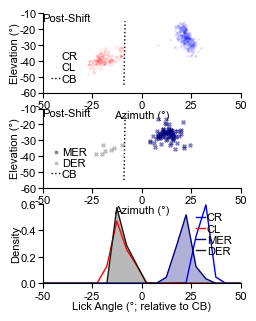

In [30]:
figName = 'Fig1_Alt_postShift_errorDistributions_splitError.pdf'
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.2
)
fontsize = 8
ms1 = 3
ms2 = 5
figSize = [2.2,3]
xlim1 = [-155,-25]
xlim1 = [-50,50]
xlim2 = [-50,50]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
yticks1 = [-10,-20,-30,-40,-50,-60]
ylim1 = [-60,-10]
ylim2 = [0,0.6]
#sColors = [(0,0,1),(1,0,0)]
sColors = [(0,0,1), (0,0,0.5), (1,0,0), (0.5,0.5,0.5)]
labels = ['CR', 'MER', 'CL', 'DER']
azi_shift = 0
histMeth = 'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]
loc='lower left'
linewidth = 1
postMask = jsm.get_behaviorShiftMask(tracker, 'post')

fig, axs = jsm.clean_subplots(3,1,figsize=figSize,gridspec_kw=gridspec_kw)
axs = axs.flatten()
w = CB.coef_[0]
C = CB.intercept_[0]
A, B = w[0], w[1]

xOffsets = [0,-10]
meMask = np.logical_and(np.logical_and(postMask, me), tracker[:,2]==5)
deMask = np.logical_and(np.logical_and(postMask, de), tracker[:,2]==5)
clMask = np.logical_and(postMask, tracker[:,2]==1)
crMask = np.logical_and(postMask, tracker[:,2]==0)
masks = [crMask, meMask, clMask, deMask]
markers = ['.','x','.','x']
alphas = [.1,.5,.1,.5]
sizes = [4,6,4,6]
handels = []

ax = axs[0]
indicies = [0,2]
for t in indicies:
    mask = masks[t]
    if markers[t] == 'x':
        for ii,i in enumerate(list(np.argwhere(mask==True))):
            if ii == 0:
                ax.plot(azi[i]+azi_shift, ele[i], markers[t], ms = sizes[t], color = sColors[t], alpha=alphas[t],label=labels[t], linestyle='None', markeredgewidth=0, markeredgecolor='none')
            else:
                ax.plot(azi[i]+azi_shift, ele[i], markers[t], ms = sizes[t], color = sColors[t], alpha=alphas[t], linestyle='None', markeredgewidth=0, markeredgecolor='none')
    else:
        for ii,i in enumerate(list(np.argwhere(mask==True))):
            if ii == 0:
                ax.plot(azi[i]+azi_shift, ele[i], markers[t], ms = sizes[t], color = sColors[t], alpha=alphas[t],label=labels[t], linestyle='None', markeredgewidth=0, markeredgecolor='none')
            else:
                ax.plot(azi[i]+azi_shift, ele[i], markers[t], ms = sizes[t], color = sColors[t], alpha=alphas[t], linestyle='None', markeredgewidth=0, markeredgecolor='none')

    handels.append(sct)
    print(f'{labels[t]} {np.sum(mask==True)}')
ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.set_yticks(yticks1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize,labelpad=0)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize,labelpad=0)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin+5, ymax-5],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    LDALine, = ax.plot([x1+azi_shift, x2+azi_shift], [ymin+5, ymax-5], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
    
ax.text(xlim1[0],ylim1[1],'Post-Shift',color = (0,0,0),fontsize=fontsize,ha='left',va='top')
ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

ax = axs[1]
indicies = [1,3]
for t in indicies:
    mask = masks[t]
    if markers[t] == 'x':
        sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])
    else:
        sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t],edgecolor=None)
    handels.append(sct)
    print(f'{labels[t]} {np.sum(mask==True)}')

ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.set_yticks(yticks1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize,labelpad=0)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize,labelpad=0)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin+5, ymax-5],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    LDALine, = ax.plot([x1+azi_shift, x2+azi_shift], [ymin+5, ymax-5], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
    
ax.text(xlim1[0],ylim1[1],'Post-Shift',color = (0,0,0),fontsize=fontsize,ha='left',va='top')
ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

ax = axs[2]
loc='upper right'
masks = [crMask, clMask, meMask, deMask]
labels = ['CR','CL','MER','DER']
linestyles = ['-','-','-','-']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.9,.9,.3,.3]
fills = [False,False,True,True]
for m, mask in enumerate(masks):
    if histMeth == 'kde':
        sns.kdeplot(cDists[mask]*-1, alpha = alphas[m], color = colors[m], ax = axs[1], fill = fills[m], lw = linewidth)
        ax.plot(-100,-100,'-',lw=linewidth,color=colors[m],label=labels[m])
    elif histMeth == 'pdf':
        tempStat = jsm.summary_stats(cDists[mask]*-1,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
            calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
            calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
            save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
        if fills[m]:
            ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = colors[m], alpha = alphas[m],edgecolor = 'none')

        ax.plot(tempStat['binCenters'],tempStat['pdf'],  color = colors[m], lw = linewidth,ls=linestyles[m],label = labels[m])

ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize,labelpad=0)
ax.set_ylabel('Density',fontsize=fontsize,labelpad=0)
ax.set_xticks(xticks2)
ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
ax.set_ylim(ylim2)
ax.set_xlim(xlim2)
for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #


plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

/tmp/ipykernel_982604/6871077.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(azi[mask]+azi_shift, ele[mask], s=5, c=sColors[t], alpha=0.1)


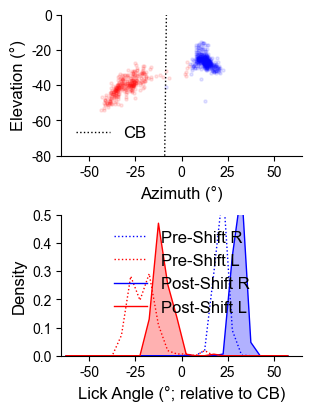

In [31]:
figName = 'Fig1_Alt_lick_locations_pre_post.pdf'

fontsize = 12
figSize = [3,4]
xlim1 = [-65,65]
xlim1 = [-65,65]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.1]
ylim2 = [0,0.5]
titles = ['Pre-Shift', 'Post-Shift']
sColors = [(0,0,1),(1,0,0)]
labels = ['Right', 'Left']
azi_shift = 0
histMeth = 'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]

sm = tracker[:,0] < 0
postMask = jsm.get_behaviorShiftMask(tracker,'post')
rTs = np.where(tracker[sm,2]==0)[0]
rT = rTs[10]
lTs = np.where(tracker[sm,2]==1)[0]
lT = lTs[10]

fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

w = CB.coef_[0]
b = CB.intercept_[0]

exampleTrials = [rT, lT]
xOffsets = [0,-10]
for t in range(2):
    mask = np.logical_and(tracker[:,0]<0, tracker[:,2]==t)
    ax.scatter(azi[mask]+azi_shift, ele[mask], s=5, c=sColors[t], alpha=0.1)

ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
ax.legend(frameon=False, loc = 'lower left',fontsize=fontsize)

ax = axs[1]

if histMeth == 'kde':
    sns.kdeplot(cDists[np.logical_and(tracker[:,0]<0, tracker[:,2]==0)]*-1, alpha = 0.3, color = (0,0,1), ax = axs[1], fill = True)
    sns.kdeplot(cDists[np.logical_and(tracker[:,0]<0, tracker[:,2]==1)]*-1, alpha = 0.3, color = (1,0,0), ax = axs[1], fill = True)
    sns.kdeplot(cDists[np.logical_and(postMask, tracker[:,2]==0)]*-1, alpha = 0.8, color = (0,0,1), ax = axs[1], fill = False)
    sns.kdeplot(cDists[np.logical_and(postMask, tracker[:,2]==1)]*-1, alpha = 0.8, color = (1,0,0), ax = axs[1], fill = False)
elif histMeth == 'pdf':
    tempData = cDists[np.logical_and(tracker[:,0]<0, tracker[:,2]==0)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (0,0,1), lw = 1,ls=':',label = 'Pre-Shift R')

    tempData = cDists[np.logical_and(tracker[:,0]<0, tracker[:,2]==1)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (1,0,0), lw = 1,ls=':',label = 'Pre-Shift L')

    tempData = cDists[np.logical_and(postMask, tracker[:,2]==0)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = (0,0,1), alpha = 0.3,edgecolor = 'none')
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (0,0,1), lw = 1,label = 'Post-Shift R')

    tempData = cDists[np.logical_and(postMask, tracker[:,2]==1)]*-1
    tempStat = jsm.summary_stats(tempData,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
        calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
        calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
        save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
    ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = (1,0,0), alpha = 0.3,edgecolor = 'none')
    ax.plot(tempStat['binCenters'],tempStat['pdf'], color = (1,0,0), lw = 1,label = 'Post-Shift L')

    ax.legend(frameon=False, loc = 'upper center',fontsize=fontsize)
ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
ax.set_ylabel('Density',fontsize=fontsize)
ax.set_xticks(xticks2)

ax.set_ylim(ylim2)
ax.set_xlim(xlim2)

for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #

plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


/tmp/ipykernel_982604/714523311.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(azi[mask],ele[mask], s = 5, c = sColors[t], alpha = 0.1,label = labels[t])
/tmp/ipykernel_982604/714523311.py:32: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(azi[mask], ele[mask], s = 20, c = errColors[m], alpha = 0.4, marker = 'x',label = labels[t]+" Error")


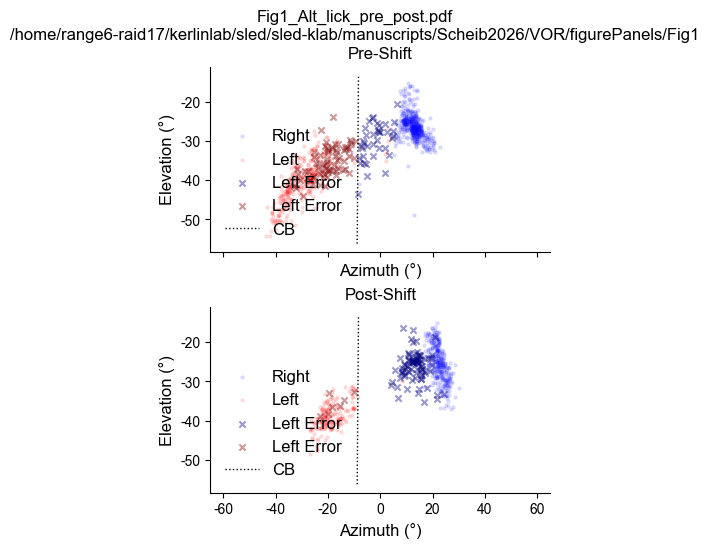

In [32]:
figName = 'Fig1_Alt_lick_pre_post.pdf'
fontsize = 12
figSize = [4,5]
sColors = [(0,0,1),(1,0,0)]
errColors = [(0,0,0.5),(0.5,0,0)]
labels = ['Right', 'Left']
xlim = [-65,65]
#############################
fig, axs = jsm.clean_subplots(2,1,figsize=figSize,sharey=True,sharex=True,constrained_layout=True)
titles = ['Pre-Shift', 'Post-Shift']
for a, ax in enumerate(axs):
    for t in range(2):
        if a==0:
            mask = np.logical_and(tracker[:,0]<0, tracker[:,2]==t)
        else:
            mask = np.logical_and(tracker[:,0]==0, tracker[:,1]>100)
            mask = np.logical_or(mask, tracker[:,0]>0)
            mask = np.logical_and(mask, tracker[:,2]==t)
        ax.scatter(azi[mask],ele[mask], s = 5, c = sColors[t], alpha = 0.1,label = labels[t])
    ax.set_title(titles[a],fontsize=fontsize)
    ax.set_ylabel('Elevation (°)',fontsize=fontsize)
    ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
for a, ax in enumerate(axs):
    if a == 0:
        mask1 = np.logical_and(tracker[:,0]<0, tracker[:,2]==5)
    else:
        mask1 = np.logical_and(tracker[:,0]==0, tracker[:,1]>100)
        mask1 = np.logical_or(mask1, tracker[:,0]>0)
        mask1 = np.logical_and(mask1, tracker[:,2]==5)
    for m, errType in enumerate([me,de]):
        mask = np.logical_and(mask1, errType)
        ax.scatter(azi[mask], ele[mask], s = 20, c = errColors[m], alpha = 0.4, marker = 'x',label = labels[t]+" Error")
for ax in axs:
    ax.spines[['top','right']].set_visible(False)

w = CB.coef_[0]
b = CB.intercept_[0]
m = -w[0] / w[1]
c = -b / w[1]

xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
yrng = m * xrng + c

ymin, ymax = ax.get_ylim()
x1 = (ymin - c) / m
x2 = (ymax - c) / m
for ax in axs:
    ax.plot([x1, x2], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label='CB')

for a, ax in enumerate(axs):
    ax.legend(frameon=False, loc = 'lower left',fontsize=fontsize)
    ax.set_xlim(xlim)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #

jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

/tmp/ipykernel_982604/1647609862.py:44: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])


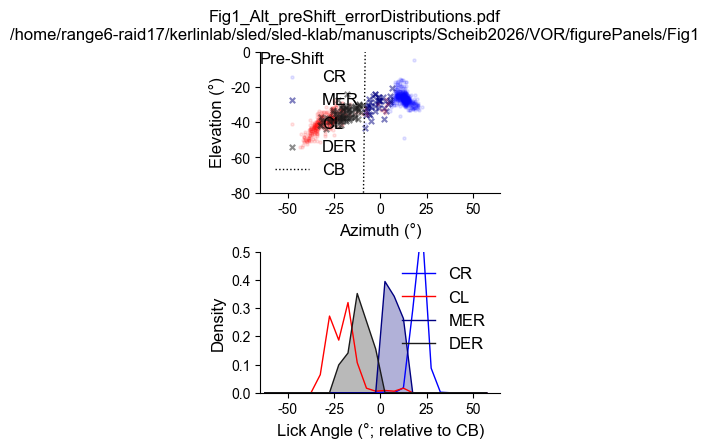

In [33]:
figName = 'Fig1_Alt_preShift_errorDistributions.pdf'

fontsize = 12
figSize = [3,4]
# xlim1 = [-155,-25]
xlim1 = [-65,65]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.5]
#sColors = [(0,0,1),(1,0,0)]
sColors = [(0,0,1), (0,0,0.5), (1,0,0), (0.1,0.1,0.1)]
labels = ['CR', 'MER', 'CL', 'DER']
azi_shift = 0
histMeth = 'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]

linewidth = 1
preMask = jsm.get_behaviorShiftMask(tracker, 'pre')

fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

w = CB.coef_[0]
C = CB.intercept_[0]
A, B = w[0], w[1]

xOffsets = [0,-10]
meMask = np.logical_and(np.logical_and(preMask, me), tracker[:,2]==5)
deMask = np.logical_and(np.logical_and(preMask, de), tracker[:,2]==5)
clMask = np.logical_and(preMask, tracker[:,2]==1)
crMask = np.logical_and(preMask, tracker[:,2]==0)
masks = [crMask, meMask, clMask, deMask]
#masks = [meMask, deMask]
markers = ['o','x','o','x']
alphas = [.1,.5,.1,.5]
sizes = [5,15,5,15]
handels = []
for t in range(4):
    mask = masks[t]
    sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])
    handels.append(sct)

ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    LDALine, = ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')

ax.text(xlim1[0],ylim1[1],'Pre-Shift',color = (0,0,0),fontsize=fontsize,ha='left',va='top')
ax.legend(loc='lower left', frameon=False,fontsize=fontsize)


ax = axs[1]
masks = [crMask, clMask, meMask, deMask]
labels = ['CR','CL','MER','DER']
linestyles = ['-','-','-','-']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.9,.9,.3,.3]
fills = [False,False,True,True]
for m, mask in enumerate(masks):
    if histMeth == 'kde':
        sns.kdeplot(cDists[mask]*-1, alpha = alphas[m], color = colors[m], ax = axs[1], fill = fills[m], lw = linewidth)
        ax.plot(-100,-100,'-',lw=linewidth,color=colors[m],label=labels[m])
    elif histMeth == 'pdf':
        tempStat = jsm.summary_stats(cDists[mask]*-1,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
            calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
            calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
            save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
        if fills[m]:
            ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = colors[m], alpha = alphas[m],edgecolor = 'none')

        ax.plot(tempStat['binCenters'],tempStat['pdf'],  color = colors[m], lw = linewidth,ls=linestyles[m],label = labels[m])

ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
ax.set_ylabel('Density',fontsize=fontsize)
ax.set_xticks(xticks2)
ax.legend(frameon=False,fontsize=fontsize)
ax.set_ylim(ylim2)
ax.set_xlim(xlim2)
for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #

jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

/tmp/ipykernel_982604/1103594876.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])


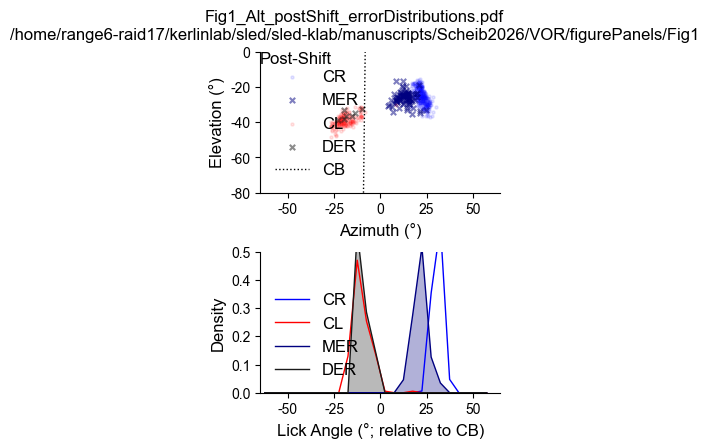

In [34]:
figName = 'Fig1_Alt_postShift_errorDistributions.pdf'

fontsize = 12
figSize = [3,4]
xlim1 = [-155,-25]
xlim1 = [-65,65]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks1 = [-50,-25,0,25,50]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.5]
#sColors = [(0,0,1),(1,0,0)]
sColors = [(0,0,1), (0,0,0.5), (1,0,0), (0.1,0.1,0.1)]
labels = ['CR', 'MER', 'CL', 'DER']
azi_shift = 0
histMeth = 'pdf'# 'kde' #pdf
binWidth = 5
binRange = [-65,65]

linewidth = 1
postMask = jsm.get_behaviorShiftMask(tracker, 'post')

fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

w = CB.coef_[0]
C = CB.intercept_[0]
A, B = w[0], w[1]

xOffsets = [0,-10]
meMask = np.logical_and(np.logical_and(postMask, me), tracker[:,2]==5)
deMask = np.logical_and(np.logical_and(postMask, de), tracker[:,2]==5)
clMask = np.logical_and(postMask, tracker[:,2]==1)
crMask = np.logical_and(postMask, tracker[:,2]==0)
masks = [crMask, meMask, clMask, deMask]
markers = ['o','x','o','x']
alphas = [.1,.5,.1,.5]
sizes = [5,15,5,15]
handels = []
for t in range(4):
    mask = masks[t]
    sct = ax.scatter(azi[mask]+azi_shift, ele[mask], s=sizes[t], c=sColors[t], alpha=alphas[t], marker = markers[t], label = labels[t])
    handels.append(sct)

ax.set_xlim(xlim1)
ax.set_xticks(xticks1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_ylim(ylim1)
ax.set_ylabel('Elevation (°)',fontsize=fontsize)
ax.set_xlabel('Azimuth (°)',fontsize=fontsize)
xrng = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
yrng = (-A/B) * xrng - (C/B)
ymin, ymax = ax.get_ylim()

if abs(B) < 1e-12:
    xline = -C / A
    ax.plot([xline+azi_shift, xline+azi_shift], [ymin, ymax],  ls = ':',color=(0,0,0), linewidth = 2,label='CB')
else:
    x1 = (ymin + (C/B)) / (-A/B) 
    x2 = (ymax + (C/B)) / (-A/B)
    LDALine, = ax.plot([x1+azi_shift, x2+azi_shift], [ymin, ymax], ls = ':',color=(0,0,0), linewidth = 1,label = 'CB')
    
ax.text(xlim1[0],ylim1[1],'Post-Shift',color = (0,0,0),fontsize=fontsize,ha='left',va='top')
ax.legend(loc='lower left', frameon=False,fontsize=fontsize)

ax = axs[1]
masks = [crMask, clMask, meMask, deMask]
labels = ['CR','CL','MER','DER']
linestyles = ['-','-','-','-']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.9,.9,.3,.3]
fills = [False,False,True,True]
for m, mask in enumerate(masks):
    if histMeth == 'kde':
        sns.kdeplot(cDists[mask]*-1, alpha = alphas[m], color = colors[m], ax = axs[1], fill = fills[m], lw = linewidth)
        ax.plot(-100,-100,'-',lw=linewidth,color=colors[m],label=labels[m])
    elif histMeth == 'pdf':
        tempStat = jsm.summary_stats(cDists[mask]*-1,nBins=0,binWidth=binWidth,temp_minVal=binRange[0],temp_maxVal=binRange[1],\
            calcHist=True, verbose=False, allow_overages = False, splitZeroBin = False, \
            calc_hist_log10 = False, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = True, 
            save_input = False, force_dType=False, dType='float32', exclude_NaNs = True, warningsOn = True)        
        if fills[m]:
            ax.fill_between(tempStat['binCenters'], np.zeros_like(tempStat['binCenters']), tempStat['pdf'], color = colors[m], alpha = alphas[m],edgecolor = 'none')

        ax.plot(tempStat['binCenters'],tempStat['pdf'],  color = colors[m], lw = linewidth,ls=linestyles[m],label = labels[m])

ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
ax.set_ylabel('Density',fontsize=fontsize)
ax.set_xticks(xticks2)
ax.legend(frameon=False,fontsize=fontsize)
ax.set_ylim(ylim2)
ax.set_xlim(xlim2)
for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #


jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


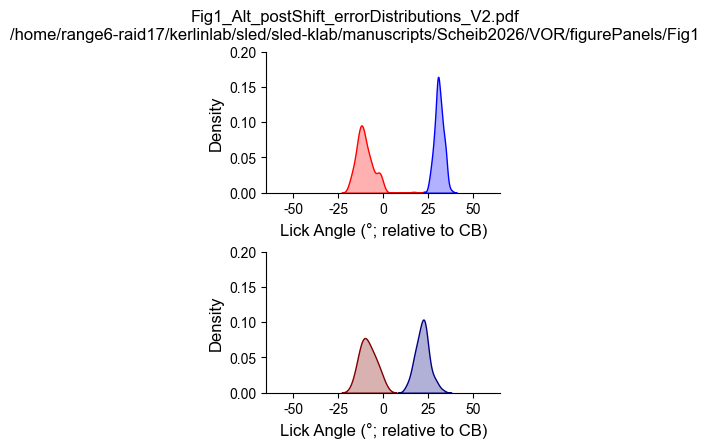

In [35]:
figName = 'Fig1_Alt_postShift_errorDistributions_V2.pdf'

fontsize = 12
figSize = [3,4]
xlim1 = [-155,-25]
xlim2 = [-65,65]
xticks1 = [-150,-125,-100,-75,-50,-25]
xticks2 = [-50,-25,0,25,50]
ylim1 = [-80,0]
ylim2 = [0,0.2]
titles = ['Pre-Shift', 'Post-Shift']
#sColors = [(0,0,1),(1,0,0)]
sColors = [[(0,0,1), (1,0,0)],[(0,0,0.5),(0.5,0,0)]]
labels = [['CR','CL'],['MER','DER']]

postMask = jsm.get_behaviorShiftMask(tracker, 'post')
fig, axs = jsm.clean_subplots(2,1,figsize=figSize,constrained_layout=True)
ax = axs[0]

meMask = np.logical_and(np.logical_and(postMask, me), tracker[:,2]==5)
deMask = np.logical_and(np.logical_and(postMask, de), tracker[:,2]==5)
clMask = np.logical_and(postMask, tracker[:,2]==1)
crMask = np.logical_and(postMask, tracker[:,2]==0)
masks = [[crMask, clMask],[meMask, deMask]]

for i in range(2):
    ax = axs[i]
    for m in range(2):
        sns.kdeplot(cDists[masks[i][m]]*-1, alpha = .3, color = sColors[i][m], fill = True, ax = ax)

    ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
    ax.set_ylabel('Density',fontsize=fontsize)
    ax.set_xticks(xticks2)
    
    ax.set_ylim(ylim2)
    ax.set_xlim(xlim2)
for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #


jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


# all animal lick angles and motor errors across shift

### setup

In [36]:
for anm in anms:
    anmData = allAnmParams[anm]
    for i,mod in enumerate(['f','c', 's']):
        azi = anmData[f'{mod}Azi']
        ele = anmData[f'{mod}Ele']
        lda = anmData['lda']
        lickAngles = jsm.get_lickAngle(azi, ele, lda)
        anmData[f'{mod}Angles'] = lickAngles

### summary stats

pre DER 0.067
pre MER 0.026
post DER 0.029
post MER 0.298


/tmp/ipykernel_982604/1323242323.py:16: RuntimeWarning: invalid value encountered in scalar divide
  percME = np.sum((me)&(prMask))/np.sum(prMask)
/tmp/ipykernel_982604/1323242323.py:17: RuntimeWarning: invalid value encountered in scalar divide
  percDE = np.sum((de)&(prMask))/np.sum(prMask)


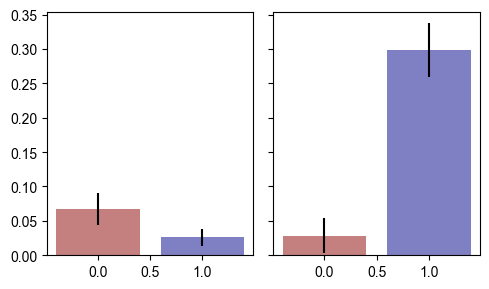

In [37]:
### % MER/ DER

stats = {'pre_percMER': [], 'pre_percDER': [], 'post_percMER': [], 'post_percDER': []}
statKeys = stats.keys()
for anm in anms:
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    me = anmData['me']
    de = anmData['de']

    for p, phase in enumerate(['pre','post']):
        rMask = (tracker[:,2]==0)|(tracker[:,2]==5)
        pMask = anmData['shiftMask'][phase]
        prMask = (pMask)&(rMask)
        
        percME = np.sum((me)&(prMask))/np.sum(prMask)
        percDE = np.sum((de)&(prMask))/np.sum(prMask)
        stats[f'{phase}_percMER'].append(percME)
        stats[f'{phase}_percDER'].append(percDE)

fig, axs = plt.subplots(1,2,figsize = [5,3],tight_layout = True, sharey = True)
colors = ['darkred', 'darkblue']
errLabels = ['DER', 'MER']
for a, ax in enumerate(axs):
    if a == 0:
        phase = 'pre'
    else:
        phase = 'post'
    pMer = stats[f'{phase}_percMER']
    pDer = stats[f'{phase}_percDER']
    errs = [pDer, pMer]
    for e, err in enumerate(errs):
        median = np.nanmedian(err)
        print(phase, errLabels[e], f'{median:.03f}')
        sem = np.nanstd(err)/np.sqrt(np.sum(np.isfinite(err)))
        ax.bar(e, median, yerr = sem, color = colors[e], alpha = 0.5)

pre: 
{'bic_1_component': 16726.951086853216, 'bic_2_component': 16755.318730006264, 'delta_bic': -28.36764315304754, 'preferred_model': '1-component', 'means': array([-12.87546624,   0.87027275]), 'mid_point': -6.002596745638087, 'variances': array([72.50234295, 80.52611946]), 'weights': array([0.44733768, 0.55266232]), 'ashman_d': 1.571437032378703}

post: 
{'bic_1_component': 37226.95590920802, 'bic_2_component': 36551.45275915414, 'delta_bic': 675.5031500538826, 'preferred_model': '2-component', 'means': array([-1.32024974, 17.38184113]), 'mid_point': 8.03079569304238, 'variances': array([119.72199885,  50.33877037]), 'weights': array([0.29916135, 0.70083865]), 'ashman_d': 2.0281641001121513}



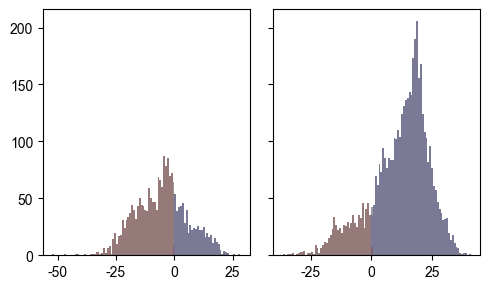

In [38]:
### test for modality
from sklearn.mixture import GaussianMixture

errAngles = {'pre_MER': [], 'pre_DER': [], 'post_MER': [], 'post_DER': []}
statKeys = errAngles.keys()
for anm in anms:
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    me = anmData['me']
    de = anmData['de']

    angles = anmData['cAngles']

    for p, phase in enumerate(['pre','post']):
        rMask = (tracker[:,2]==0)|(tracker[:,2]==5)
        pMask = anmData['shiftMask'][phase]
        prMask = (pMask)&(rMask)
        
        meAngles = angles[(me)&(prMask)]
        deAngles = angles[(de)&(prMask)]
        errAngles[f'{phase}_MER'].append(meAngles)
        errAngles[f'{phase}_DER'].append(deAngles)

modeTests = {}
random_state = 73

fig, axs = plt.subplots(1,2,figsize = [5,3],tight_layout = True, sharey = True)
colors = ['darkred', 'darkblue']
errLabels = ['DER', 'MER']

for p, phase in enumerate(['pre','post']):

    X = np.hstack([np.hstack(errAngles[f'{phase}_MER']), np.hstack(errAngles[f'{phase}_DER'])])*-1
    X = X[np.isfinite(X)]
    
    _,bins = np.histogram(X, bins =100)
    axs[p].hist(X, color = 'k', alpha = 0.4, bins = bins);
    axs[p].hist(np.hstack(errAngles[f'{phase}_MER'])*-1, color = 'darkblue', alpha = 0.2, bins = bins);
    axs[p].hist(np.hstack(errAngles[f'{phase}_DER'])*-1, color = 'darkred', alpha = 0.2, bins = bins);
    
    X = X.reshape(-1,1)
    
    # Fit models
    gmm1 = GaussianMixture(n_components=1, random_state=random_state)
    gmm2 = GaussianMixture(n_components=2, random_state=random_state)
    
    gmm1.fit(X)
    gmm2.fit(X)
    
    # Compute BIC
    bic1 = gmm1.bic(X)
    bic2 = gmm2.bic(X)
    
    delta_bic = bic1 - bic2  # positive favors 2-component
    
    # Extract parameters for interpretability
    means = gmm2.means_.flatten()
    variances = gmm2.covariances_.flatten()
    weights = gmm2.weights_.flatten()
    
    # Sort components by mean
    order = np.argsort(means)
    means = means[order]
    variances = variances[order]
    weights = weights[order]
    
    # Optional: Ashman's D
    ashman_d = np.abs(means[1] - means[0]) / np.sqrt(0.5 * (variances[0] + variances[1]))
    
    output =  {
            "bic_1_component": bic1,
            "bic_2_component": bic2,
            "delta_bic": delta_bic,
            "preferred_model": "2-component" if delta_bic > 0 else "1-component",
            "means": means,
            'mid_point': np.mean(means),
            "variances": variances,
            "weights": weights,
            "ashman_d": ashman_d
        }

    modeTests[phase] = output

for phase in ['pre','post']:
    print(f'{phase}: ')
    print(modeTests[phase])
    print('')

pre DEL 0.066328
pre MEL 0.000000
pre errRatio 0.082850
post DEL 0.005201
post MEL 0.000000
post errRatio 0.005201


/tmp/ipykernel_982604/3389956301.py:15: RuntimeWarning: invalid value encountered in scalar divide
  percME = np.sum((me)&(plMask))/np.sum(plMask)
/tmp/ipykernel_982604/3389956301.py:16: RuntimeWarning: invalid value encountered in scalar divide
  percDE = np.sum((de)&(plMask))/np.sum(plMask)
/tmp/ipykernel_982604/3389956301.py:22: RuntimeWarning: invalid value encountered in scalar divide
  statsL[f'{phase}_ratio'].append(nAny/np.sum(plMask))


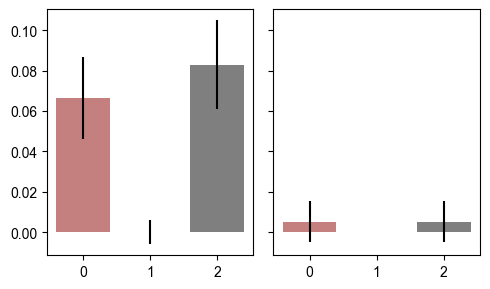

In [39]:
statsL = {'pre_percMEL': [], 'pre_percDEL': [], 'pre_ratio': [],
          'post_percMEL': [], 'post_percDEL': [], 'post_ratio': []}
statLKeys = statsL.keys()
for anm in anms:
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    me = anmData['me']
    de = anmData['de']

    for p, phase in enumerate(['pre','post']):
        lMask = (tracker[:,2]==1)|(tracker[:,2]==6)
        pMask = anmData['shiftMask'][phase]
        plMask = (pMask)&(lMask)
        
        percME = np.sum((me)&(plMask))/np.sum(plMask)
        percDE = np.sum((de)&(plMask))/np.sum(plMask)
        statsL[f'{phase}_percMEL'].append(percME)
        statsL[f'{phase}_percDEL'].append(percDE)

        nAny = (np.sum(((me)|(de))&(plMask)))
        
        statsL[f'{phase}_ratio'].append(nAny/np.sum(plMask))

fig, axs = plt.subplots(1,2,figsize = [5,3],tight_layout = True, sharey = True)
colors = ['darkred', 'darkblue', 'k']
errLabels = ['DEL', 'MEL', 'errRatio']
for a, ax in enumerate(axs):
    if a == 0:
        phase = 'pre'
    else:
        phase = 'post'
    pMel = statsL[f'{phase}_percMEL']
    pDel = statsL[f'{phase}_percDEL']
    ratio = statsL[f'{phase}_ratio']
    errs = [pDel, pMel, ratio]
    for e, err in enumerate(errs):
        median = np.nanmedian(err)
        print(phase, errLabels[e], f'{median:.06f}')
        sem = np.nanstd(err)/np.sqrt(np.sum(np.isfinite(err)))
        ax.bar(e, median, yerr = sem, color = colors[e], alpha = 0.5, label = errLabels[e])

/tmp/ipykernel_982604/4150720555.py:15: RuntimeWarning: invalid value encountered in scalar divide
  percME = np.sum((me)&(paMask))/np.sum(paMask)
/tmp/ipykernel_982604/4150720555.py:16: RuntimeWarning: invalid value encountered in scalar divide
  percDE = np.sum((de)&(paMask))/np.sum(paMask)
/tmp/ipykernel_982604/4150720555.py:21: RuntimeWarning: invalid value encountered in scalar divide
  ratio = np.sum((de)&(paMask))/nAny
/tmp/ipykernel_982604/4150720555.py:24: RuntimeWarning: invalid value encountered in scalar divide
  statsAny[f'{phase}_err_toCorrect'].append(nAny/np.sum(paMask))


pre DE 0.094
pre ME 0.019
pre DE/DE+ME 0.813
pre errors 0.117

post DE 0.024
post ME 0.183
post DE/DE+ME 0.143
post errors 0.253



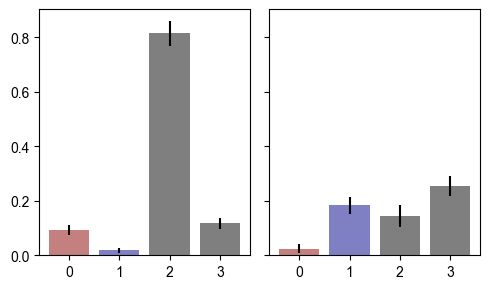

In [40]:
statsAny = {'pre_percME': [], 'pre_percDE': [], 'pre_ratio': [], 'pre_err_toCorrect': [],
            'post_percME': [], 'post_percDE': [], 'post_ratio': [], 'post_err_toCorrect': []}
statsAnyKeys = statsAny.keys()
for anm in anms:
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    me = anmData['me']
    de = anmData['de']

    for p, phase in enumerate(['pre','post']):
        aMask = tracker[:,2]<10 #only clean trials (no EL)
        pMask = anmData['shiftMask'][phase]
        paMask = (pMask)&(aMask)
        
        percME = np.sum((me)&(paMask))/np.sum(paMask)
        percDE = np.sum((de)&(paMask))/np.sum(paMask)
        statsAny[f'{phase}_percME'].append(percME)
        statsAny[f'{phase}_percDE'].append(percDE)

        nAny = (np.sum(((me)|(de))&(paMask)))
        ratio = np.sum((de)&(paMask))/nAny
        statsAny[f'{phase}_ratio'].append(ratio)

        statsAny[f'{phase}_err_toCorrect'].append(nAny/np.sum(paMask))

fig, axs = plt.subplots(1,2,figsize = [5,3],tight_layout = True, sharey = True)
colors = ['darkred', 'darkblue', 'k', 'k']
errLabels = ['DE', 'ME', 'DE/DE+ME', 'errors']
for a, ax in enumerate(axs):
    if a == 0:
        phase = 'pre'
    else:
        phase = 'post'
    pMe = statsAny[f'{phase}_percME']
    pDe = statsAny[f'{phase}_percDE']
    ratio = statsAny[f'{phase}_ratio']
    errors = statsAny[f'{phase}_err_toCorrect']
    errs = [pDe, pMe, ratio, errors]
    for e, err in enumerate(errs):
        median = np.nanmedian(err)
        print(phase, errLabels[e], f'{median:.03f}')
        sem = np.nanstd(err)/np.sqrt(np.sum(np.isfinite(err)))
        ax.bar(e, median, yerr = sem, color = colors[e], alpha = 0.5)
    print('')

In [41]:
### response times
pre = []
post = []
change = []
for anm in anms:
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    preMask = anmData['shiftMask']['pre']
    postMask = anmData['shiftMask']['post']
    goCues = anmData['goCues']
    cTimes = anmData['cTimes']
    rxTime = cTimes-goCues
    pre.append(np.nanmean(rxTime[preMask]))
    post.append(np.nanmean(rxTime[postMask]))
    if np.sum(postMask>0):
        change.append(np.nanmean(rxTime[postMask])-np.nanmean(rxTime[preMask]))
print('pre: ', f'{np.nanmedian(pre):.03f}')
print('post: ', f'{np.nanmedian(post):.03f}')
# print('change: ', f'{np.nanmean(post)-np.nanmean(pre):.03f}')
print('change: ', f'{np.nanmean(change):.03f}', f'{np.nanstd(change):.03f}')

pre:  0.219
post:  0.284
change:  0.057 0.059


/tmp/ipykernel_982604/104168813.py:14: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(rxTime[postMask]))


### figure panels

Pre Shift CR n = 10609
Pre Shift CL n = 9302
Pre Shift MER n = 647
Pre Shift DER n = 1536
Post Shift CR n = 6568
Post Shift CL n = 4717
Post Shift MER n = 4010
Post Shift DER n = 754


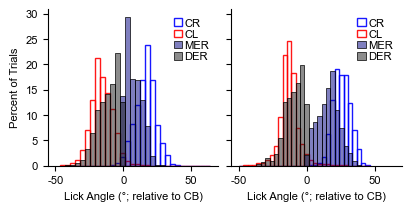

In [42]:
figName = 'Fig1_allAnmLickDistro.pdf'

ttypes = ['CR','CL','MER','DER']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.9,.9,.5,.5]
fontsize = 8
figsize = [4,2]
titles = ['Pre Shift', 'Post Shift']
CI = 68
error = 'std'
# ylim = [-7,3]
ylim = [-3,7]
if error == 'CI':
    errorLabel = "mean±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "mean±SEM"
elif error == 'std':
    errorLabel = "mean±SD"
nBoot = 10000

fig,axs = jsm.clean_subplots(1,2,figsize,constrained_layout=True,sharey = True, sharex=True)
for q in range(2):
    ax = axs[q]

    allAnmDistros = [[],[],[],[]]
    for a, anm in enumerate(anms):
        anmData = allAnmParams[anm]
        if q == 0:
            phaseMask = allAnmParams[anm]['shiftMask']['pre']
        else:
            phaseMask = allAnmParams[anm]['shiftMask']['post']

        tracker = allAnmParams[anm]['tracker']#jsm.get_tracker(anmData)
        azi = allAnmParams[anm]['cAzi']+90
        ele = allAnmParams[anm]['cEle']    
        me, de, CB = jsm.get_errors_LDA(azi, ele, tracker, returnLDA = True)

        dists = jsm.get_lickAngle(azi, ele, CB)
        CR = tracker[:,2]==0
        CL = tracker[:,2]==1
        me = (allAnmParams[anm]['me'])&(tracker[:,2]==5)
        de = (allAnmParams[anm]['de'])&(tracker[:,2]==5)
        ttypeMasks = [CR,CL,me,de]
        distros = []
        for m, mask in enumerate(ttypeMasks):
            allAnmDistros[m].append(dists[(mask)&(phaseMask)])

    flatDistros = np.hstack([np.hstack(allAnmDistros[i]) for i in range(len(allAnmDistros))])
    _,bins = np.histogram(flatDistros[np.isfinite(flatDistros)], bins = 30)
    fills = [False, False, True, True]
    lws = [1,1,0.5,0.5]
    for d, distro in enumerate(allAnmDistros):
        sns.histplot(np.hstack(distro)*-1, color = colors[d], alpha = alphas[d], ax = ax, bins = bins, stat = 'percent', fill = fills[d], linewidth=lws[d],label=ttypes[d])
        print(f'{titles[q]} {ttypes[d]} n = {np.nansum(np.isfinite(np.hstack(distro)))}')
    ax.legend(frameon=False,fontsize=fontsize,loc='upper right',handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
for i in range(2):
    ax = axs[i]
    
    ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
    ax.set_ylabel('Percent of Trials',fontsize=fontsize)

for ax in axs:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize) #
    
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


Pre-Shift Right median 17.1 std 7.3 mean 16.6 ± 0.1 (n = 10609)
Pre-Shift Left median -16.4 std 8.0 mean -15.8 ± 0.1 (n = 9302)
Pre-Shift Motor median 6.6 std 5.8 mean 7.7 ± 0.2 (n = 647)
Pre-Shift Decision median -9.5 std 7.8 mean -10.8 ± 0.2 (n = 1536)
Post-Shift Right median 25.5 std 6.2 mean 25.6 ± 0.1 (n = 6568)
Post-Shift Left median -13.3 std 7.4 mean -12.9 ± 0.1 (n = 4717)
Post-Shift Motor median 16.3 std 7.8 mean 15.8 ± 0.1 (n = 4010)
Post-Shift Decision median -8.6 std 6.9 mean -9.6 ± 0.3 (n = 754)


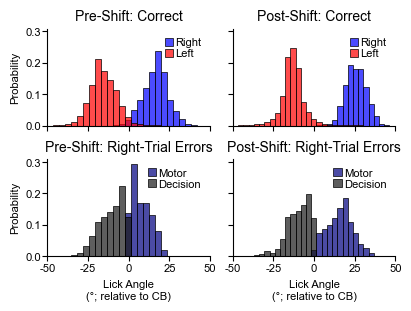

In [43]:
figName = 'Fig1_allAnmLickDistro_alt.pdf'

ttypes = ['Right','Left','Motor','Decision']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.7,.7,.7,.7]
fills = [False, False, True, True]
lws = [0.5,0.5,0.5,0.5]
fontsize = 8
figsize = [4,3]
titles = ['Pre-Shift', 'Post-Shift']
CI = 68
error = 'std'
# ylim = [-7,3]
ylim = [-3,7]
xlim = [-50,50]
xticks = [-50,-25,0,25,50]
if error == 'CI':
    errorLabel = "mean±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "mean±SEM"
elif error == 'std':
    errorLabel = "mean±SD"
nBoot = 10000

fig,axs = jsm.clean_subplots(2,2,figsize,constrained_layout=True,sharey = True, sharex=True)
for q in range(2):
    # ax = axs[q]

    allAnmDistros = [[],[],[],[]]
    for a, anm in enumerate(anms):
        anmData = allAnmParams[anm]
        if q == 0:
            phaseMask = allAnmParams[anm]['shiftMask']['pre']
        else:
            phaseMask = allAnmParams[anm]['shiftMask']['post']

        tracker = allAnmParams[anm]['tracker']#jsm.get_tracker(anmData)
        azi = allAnmParams[anm]['cAzi']+90
        ele = allAnmParams[anm]['cEle']    
        me, de, CB = jsm.get_errors_LDA(azi, ele, tracker, returnLDA = True)

        dists = jsm.get_lickAngle(azi, ele, CB)
        CR = tracker[:,2]==0
        CL = tracker[:,2]==1
        me = (allAnmParams[anm]['me'])&(tracker[:,2]==5)
        de = (allAnmParams[anm]['de'])&(tracker[:,2]==5)
        ttypeMasks = [CR,CL,me,de]
        distros = []
        for m, mask in enumerate(ttypeMasks):
            allAnmDistros[m].append(dists[(mask)&(phaseMask)])

    flatDistros = np.hstack([np.hstack(allAnmDistros[i]) for i in range(len(allAnmDistros))])
    _,bins = np.histogram(flatDistros[np.isfinite(flatDistros)], bins = 30)

    for d, distro in enumerate(allAnmDistros):
        if d<2:
            ax = axs[0,q]
            ax.set_title(titles[q]+': Correct',fontsize=fontsize+2)
        else:
            ax = axs[1,q]
            ax.set_title(titles[q]+': Right-Trial Errors',fontsize=fontsize+2)

        sns.histplot(np.hstack(distro)*-1, color = colors[d], alpha = alphas[d], ax = ax, bins = bins, stat = 'probability', linewidth=lws[d],label=ttypes[d])
        print(f'{titles[q]} {ttypes[d]} median {np.nanmedian(np.hstack(distro)*-1):.1f} std {np.nanstd(np.hstack(distro)*-1):.1f} mean {np.nanmean(np.hstack(distro)*-1):.1f} ± {np.nanstd(np.hstack(distro)*-1)/np.sqrt(np.sum(np.isfinite(np.hstack(distro)*-1))):.1f} (n = {np.nansum(np.isfinite(np.hstack(distro)))})')
for ax in axs.flatten():
    ax.legend(frameon=False,fontsize=fontsize,loc='upper right',handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3)    
    ax.set_xlabel('Lick Angle\n(°; relative to CB)',fontsize=fontsize)
    ax.set_ylabel('Probability',fontsize=fontsize)
    ax.set_xticks(xticks)
    ax.set_xlim(xlim)
for ax in axs.flatten():
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize) #
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #

plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


Pre Shift Right n = 10609
Pre Shift Left n = 9302
Pre Shift Motor n = 647
Pre Shift Decision n = 1536
Post Shift Right n = 6568
Post Shift Left n = 4717
Post Shift Motor n = 4010
Post Shift Decision n = 754


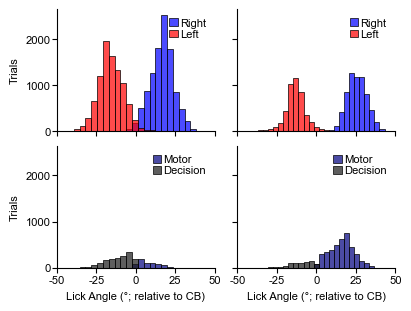

In [44]:
figName = 'Fig1_allAnmLickDistro_alt1.pdf'

ttypes = ['Right','Left','Motor','Decision']
colors = [(0,0,1),(1,0,0),(0,0,.5),(.1,.1,.1)]
alphas = [.7,.7,.7,.7]
fills = [False, False, True, True]
lws = [0.5,0.5,0.5,0.5]
fontsize = 8
figsize = [4,3]
titles = ['Pre Shift', 'Post Shift']
CI = 68
error = 'std'
# ylim = [-7,3]
ylim = [-3,7]
xlim = [-50,50]
xticks = [-50,-25,0,25,50]
if error == 'CI':
    errorLabel = "mean±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "mean±SEM"
elif error == 'std':
    errorLabel = "mean±SD"
nBoot = 10000

fig,axs = jsm.clean_subplots(2,2,figsize,constrained_layout=True,sharey = True, sharex=True)
for q in range(2):
    # ax = axs[q]

    allAnmDistros = [[],[],[],[]]
    for a, anm in enumerate(anms):
        anmData = allAnmParams[anm]
        if q == 0:
            phaseMask = allAnmParams[anm]['shiftMask']['pre']
        else:
            phaseMask = allAnmParams[anm]['shiftMask']['post']

        tracker = allAnmParams[anm]['tracker']#jsm.get_tracker(anmData)
        azi = allAnmParams[anm]['cAzi']+90
        ele = allAnmParams[anm]['cEle']    
        me, de, CB = jsm.get_errors_LDA(azi, ele, tracker, returnLDA = True)

        dists = jsm.get_lickAngle(azi, ele, CB)
        CR = tracker[:,2]==0
        CL = tracker[:,2]==1
        me = (allAnmParams[anm]['me'])&(tracker[:,2]==5)
        de = (allAnmParams[anm]['de'])&(tracker[:,2]==5)
        ttypeMasks = [CR,CL,me,de]
        distros = []
        for m, mask in enumerate(ttypeMasks):
            allAnmDistros[m].append(dists[(mask)&(phaseMask)])

    flatDistros = np.hstack([np.hstack(allAnmDistros[i]) for i in range(len(allAnmDistros))])
    _,bins = np.histogram(flatDistros[np.isfinite(flatDistros)], bins = 30)

    for d, distro in enumerate(allAnmDistros):
        if d<2:
            ax = axs[0,q]
        else:
            ax = axs[1,q]

        sns.histplot(np.hstack(distro)*-1, color = colors[d], alpha = alphas[d], ax = ax, bins = bins, linewidth=lws[d],label=ttypes[d])
        print(f'{titles[q]} {ttypes[d]} n = {np.nansum(np.isfinite(np.hstack(distro)))}')
for ax in axs.flatten():
    ax.legend(frameon=False,fontsize=fontsize,loc='upper right',handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3)    
    ax.set_xlabel('Lick Angle (°; relative to CB)',fontsize=fontsize)
    ax.set_ylabel('Trials',fontsize=fontsize)
    ax.set_xticks(xticks)
    ax.set_xlim(xlim)
for ax in axs.flatten():
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=fontsize) #
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #

plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


/tmp/ipykernel_982604/3962818901.py:68: RuntimeWarning: Mean of empty slice
  anmR[p] = np.nanmean(pDists[rMask])-preR
/tmp/ipykernel_982604/3962818901.py:69: RuntimeWarning: Mean of empty slice
  anmL[p] = np.nanmean(pDists[lMask])-preL


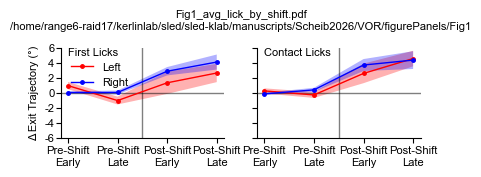

In [45]:
figName = 'Fig1_avg_lick_by_shift.pdf'
yticks = [-6,-4,-2,0,2,4,6]
ylim = [-6,6]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.2
)

colors = [(1,0,0),(0,0,1)]
fontsize = 8
figsize = [4,1]
titles = ['First Licks', 'Contact Licks']
CI = 68
error = 'std'
# ylim = [-7,3]
if error == 'CI':
    errorLabel = "mean±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "mean±SEM"
elif error == 'std':
    errorLabel = "mean±SD"
nBoot = 10000

allBooted = []

fig,axs = jsm.clean_subplots(1,2,figsize,constrained_layout=True,sharey = True, sharex=True, gridspec_kw = gridspec_kw)
axs = np.squeeze(axs)
for q in range(2):
    ax = axs[q]
    ax.axhline(0,color = (0,0,0), linestyle = '-', lw = 1, alpha = 0.5)
    ax.axvline(1.5,color = (0,0,0), linestyle = '-', lw = 1, alpha = 0.5)
    
    base = {'Left': np.zeros([len(anms), 4]), 'Right': np.zeros([len(anms), 4])}
    for a, anm in enumerate(anms):
        anmData = allAnmParams[anm]
        if q == 0:
            dists = allAnmParams[anm]['fAngles']
        else:
            dists = allAnmParams[anm]['cAngles']
        tracker = anmData['tracker']
        me = anmData['me']
    
        preMask =np.logical_or(allAnmParams[anm]['shiftMask']['preShift_early'], allAnmParams[anm]['shiftMask']['preShift_late'])
        preRMask = np.logical_and(np.logical_and(preMask, ~allAnmParams[anm]['aw']),
                                  np.logical_or(tracker[:,2]==0,np.logical_and(me,tracker[:,2]==5)))
        preR = np.nanmean(dists[preRMask])
        preLMask = np.logical_and(np.logical_and(preMask, ~allAnmParams[anm]['aw']),
                                   np.logical_or(tracker[:,2]==1,np.logical_and(me,tracker[:,2]==6)))
        preL = np.nanmean(dists[preLMask])
    
        anmR = np.zeros(4)
        anmL = np.zeros(4)
    
        for p, phase in enumerate(['preShift_early','preShift_late','early','late']):
            pMask = np.logical_and(allAnmParams[anm]['shiftMask'][phase], ~allAnmParams[anm]['aw'])
            pT = tracker[pMask,:]
            pME = me[pMask]
            pDists = dists[pMask]

            # these should be pDists<0 and >0
            rMask = np.logical_or(pT[:,2]==0,np.logical_and(pME,pT[:,2]==5))
            lMask = np.logical_or(pT[:,2]==1,np.logical_and(pME,pT[:,2]==6))
            
            anmR[p] = np.nanmean(pDists[rMask])-preR
            anmL[p] = np.nanmean(pDists[lMask])-preL
        
        base['Left'][a,:] = (anmL)*-1
        base['Right'][a,:] = (anmR)*-1
        
    base['Left'] = np.vstack(base['Left'])
    base['Right'] = np.vstack(base['Right'])
    booted = {'Left': np.zeros([nBoot,4]), 'Right': np.zeros([nBoot,4])}
    
    for i in range(nBoot):
        bAnms = np.random.choice(np.arange(len(anms)), len(anms))
        booted['Left'][i,:] = np.nanmean(base['Left'][bAnms,:],axis = 0)
        booted['Right'][i,:] = np.nanmean(base['Right'][bAnms,:],axis = 0)
    
    for i,side in enumerate(['Left', 'Right']):
        data = booted[side] #boot, phase
        mean = np.nanmean(data,axis = 0)
        med = np.nanmedian(data,axis = 0)
        std = np.nanstd(data,axis = 0, ddof = 1)
        low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        ax.fill_between(np.arange(4), errorLow, errorHigh, color = colors[i], alpha = 0.3,edgecolor = 'none')
        ax.plot(['Pre-Shift\nEarly','Pre-Shift\nLate','Post-Shift\nEarly','Post-Shift\nLate'], mainPlot, '.-', lw = 1, ms = 5, color = colors[i], label = f'{side}')

    ax.text(0,ylim[1],titles[q],ha='left',va='top',fontsize=fontsize)
    allBooted.append(booted)
    
for a,ax in enumerate(axs):
    x = 0
    y = .95
    if a == 0:
        # ax.set_ylabel('Distance\nfrom PreShift\n('+errorLabel+')',fontsize=fontsize)
        ax.set_ylabel(f'Δ Exit Trajectory (°)',fontsize=fontsize)
        # ax.legend(frameon=False,fontsize=fontsize,loc = 'lower left')
        ax.legend(frameon=False,fontsize=fontsize,loc = 'upper left',bbox_to_anchor=(x, y))
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
    ax.set_ylim(ylim)
jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir)+"\n",margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


/tmp/ipykernel_982604/1707898471.py:65: RuntimeWarning: Mean of empty slice
  anmR[p] = np.nanmean(pDists[rMask])-preR
/tmp/ipykernel_982604/1707898471.py:66: RuntimeWarning: Mean of empty slice
  anmL[p] = np.nanmean(pDists[lMask])-preL


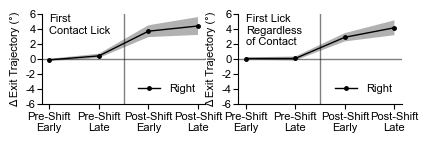

In [46]:
figName = 'Fig1_avg_lick_by_shift_R_ONLY.pdf'
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.2
)

colors = [(1,0,0),(0,0,1)]
fontsize = 8
figsize = [4,1]
titles = ['First\nContact Lick','First Lick\nRegardless\nof Contact']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "mean±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "mean±SEM"
elif error == 'std':
    errorLabel = "mean±SD"
nBoot = 10000
yticks = [-6,-4,-2,0,2,4,6]
ylim = [-6,6]
allBooted = []

fig,axs = jsm.clean_subplots(1,2,figsize,constrained_layout=True,sharey = False, sharex=True, gridspec_kw = gridspec_kw)
axs = list(np.squeeze(axs))
for q in range(2):
    ax = axs[q]
    ax.axhline(0,color = (0,0,0), linestyle = '-', lw = 1, alpha = 0.5)
    ax.axvline(1.5,color = (0,0,0), linestyle = '-', lw = 1, alpha = 0.5)
    
    base = {'Left': np.zeros([len(anms), 4]), 'Right': np.zeros([len(anms), 4])}
    for a, anm in enumerate(anms):
        anmData = allAnmParams[anm]
        if q == 0:
            dists = allAnmParams[anm]['cAngles']
        else:
            dists = allAnmParams[anm]['fAngles']
        tracker = anmData['tracker']
        me = anmData['me']
    
        preMask =np.logical_or(allAnmParams[anm]['shiftMask']['preShift_early'], allAnmParams[anm]['shiftMask']['preShift_late'])
        preRMask = np.logical_and(np.logical_and(preMask, ~allAnmParams[anm]['aw']),
                                  np.logical_or(tracker[:,2]==0,np.logical_and(me,tracker[:,2]==5)))
        preR = np.nanmean(dists[preRMask])
        preLMask = np.logical_and(np.logical_and(preMask, ~allAnmParams[anm]['aw']),
                                   np.logical_or(tracker[:,2]==1,np.logical_and(me,tracker[:,2]==6)))
        preL = np.nanmean(dists[preLMask])
    
        anmR = np.zeros(4)
        anmL = np.zeros(4)
    
        for p, phase in enumerate(['preShift_early','preShift_late','early','late']):
            pMask = np.logical_and(allAnmParams[anm]['shiftMask'][phase], ~allAnmParams[anm]['aw'])
            pT = tracker[pMask,:]
            pME = me[pMask]
            pDists = dists[pMask]

            rMask = np.logical_or(pT[:,2]==0,np.logical_and(pME,pT[:,2]==5))
            lMask = np.logical_or(pT[:,2]==1,np.logical_and(pME,pT[:,2]==6))
            
            anmR[p] = np.nanmean(pDists[rMask])-preR
            anmL[p] = np.nanmean(pDists[lMask])-preL
        
        base['Left'][a,:] = (anmL)*-1
        base['Right'][a,:] = (anmR)*-1
        
    base['Left'] = np.vstack(base['Left'])
    base['Right'] = np.vstack(base['Right'])
    booted = {'Left': np.zeros([nBoot,4]), 'Right': np.zeros([nBoot,4])}
    
    for i in range(nBoot):
        bAnms = np.random.choice(np.arange(len(anms)), len(anms))
        booted['Left'][i,:] = np.nanmean(base['Left'][bAnms,:],axis = 0)
        booted['Right'][i,:] = np.nanmean(base['Right'][bAnms,:],axis = 0)
    
    for i,side in enumerate(['Left', 'Right']):
        if side == 'Right':
            data = booted[side] #boot, phase
            mean = np.nanmean(data,axis = 0)
            std = np.nanstd(data,axis = 0, ddof = 1)
            low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std
            ax.fill_between(np.arange(4), errorLow, errorHigh, color = (0,0,0), alpha = 0.3,edgecolor = 'none')
            ax.plot(['Pre-Shift\nEarly','Pre-Shift\nLate','Post-Shift\nEarly','Post-Shift\nLate'], mainPlot, '.-', lw = 1, ms = 5, color = (0,0,0), label = f'{side}')

    ax.text(0,ylim[1],titles[q],ha='left',va='top',fontsize=fontsize)
    allBooted.append(booted)
for a,ax in enumerate(axs):
    x = 0
    y = .95
    ax.set_ylabel(f'Δ Exit Trajectory (°)',fontsize=fontsize)
    ax.legend(frameon=False,fontsize=fontsize,loc = 'lower right')
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #

plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [47]:
for b, booted in enumerate(allBooted):
    print(titles[b])
    for side in ['Right', 'Left']:
        data = booted[side]  # shape: (nBoot, 4)
    
        # Post-shift late (index 3)
        post_late = data[:, 3]
    
        mean = np.mean(post_late)
        std = np.std(post_late, ddof=1)
    
        # bootstrap p-value (two-sided)
        p = 2 * min(np.mean(post_late > 0), np.mean(post_late < 0))
    
        print(f"{side} post-shift late: {mean:.2f} ± {std:.2f}°, p = {p:.4f}")
    print('')

First
Contact Lick
Right post-shift late: 4.37 ± 1.19°, p = 0.0002
Left post-shift late: 4.57 ± 1.02°, p = 0.0000

First Lick
Regardless
of Contact
Right post-shift late: 4.13 ± 0.99°, p = 0.0000
Left post-shift late: 2.63 ± 1.20°, p = 0.0222



In [48]:
anm = 'B00002121749'
phase = 'preShift_early'
allAnmParams[anm]['shiftMask'][phase]

array([ True,  True,  True, ..., False, False, False])

B00002121749 preShift_early pMask/total 215/1341 meMask/rMask = 4/78
B00002121749 preShift_late pMask/total 355/1341 meMask/rMask = 13/103
B00002121749 early pMask/total 481/1341 meMask/rMask = 81/160
B00002121749 late pMask/total 290/1341 meMask/rMask = 25/59
B00002121774 preShift_early pMask/total 689/2920 meMask/rMask = 2/287
B00002121774 preShift_late pMask/total 385/2920 meMask/rMask = 0/167
B00002121774 early pMask/total 649/2920 meMask/rMask = 107/312
B00002121774 late pMask/total 643/2920 meMask/rMask = 130/412
B00002121777 preShift_early pMask/total 656/3216 meMask/rMask = 5/217
B00002121777 preShift_late pMask/total 394/3216 meMask/rMask = 0/146
B00002121777 early pMask/total 669/3216 meMask/rMask = 86/209
B00002121777 late pMask/total 650/3216 meMask/rMask = 99/252
B00002213772 preShift_early pMask/total 656/3370 meMask/rMask = 4/254
B00002213772 preShift_late pMask/total 426/3370 meMask/rMask = 8/183
B00002213772 early pMask/total 484/3370 meMask/rMask = 74/267
B00002213772

/tmp/ipykernel_982604/2770837300.py:36: RuntimeWarning: invalid value encountered in scalar divide
  ratio = np.sum(meMask)/np.sum(rMask)


(10000, 4)
preEarly p = 0.00000000
preLate p = 0.00000000
postEarly p = 0.00000000
postLate p = 0.00000000


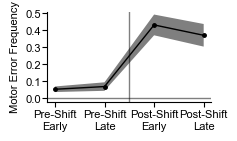

In [49]:
figName = 'Fig1_motor_error_fraction.pdf'
fontsize = 8
figsize = [4,1]
titles = ['First Licks', 'Contact Licks']
# colors = [(0,0.5,0)]
colors = [(0,0,0)]
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "mean±"+str(CI)+"% CI"
elif error == 'std':
    errorLabel = "mean±SD"
ylim = [-0.02,0.51]
yticks = [0,0.1,0.2,0.3,0.4,0.5]
fig,axs = jsm.clean_subplots(1,2,figsize,constrained_layout=True,sharey = False, sharex=True, gridspec_kw = gridspec_kw)
axs = list(np.squeeze(axs))
fig.delaxes(axs[1])

ax = axs[0]
nBoot = 10000
base = np.zeros([len(anms),4])
_nAnms = 0
for a, anm in enumerate(anms):
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    me = anmData['me']
    anmR = np.zeros(4)
    _nAnms+=1
    for p, phase in enumerate(['preShift_early','preShift_late','early','late']):
        pMask = np.logical_and(allAnmParams[anm]['shiftMask'][phase], ~allAnmParams[anm]['aw'])
        pT = tracker[pMask,:]
        pME = me[pMask]
        meMask = np.logical_and(pME,pT[:,2]==5)
        rMask = np.logical_or(pT[:,2]==0,meMask)
        
        ratio = np.sum(meMask)/np.sum(rMask)
        anmR[p] = ratio
        print(f'{anm} {phase} pMask/total {np.sum(pMask==True)}/{len(pMask)} meMask/rMask = {np.sum(meMask)}/{np.sum(rMask)}')
    base[a,:] = anmR
print('nAnms:', _nAnms)
total = np.zeros([nBoot,4])
for i in range(nBoot):
    bAnms = np.random.choice(np.arange(len(anms)), len(anms))
    total[i,:] = np.nanmean(base[bAnms,:], axis = 0)
i=0
mean = np.nanmean(total, axis=0)
med = np.nanmedian(total, axis = 0)
std = np.nanstd(total,axis = 0, ddof = 1)
sem = std / np.sqrt(total.shape[0])
low,high = np.nanpercentile(total, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
if error == 'CI':
    mainPlot = med
    errorLow = low
    errorHigh = high
elif error == 'sem':
    mainPlot = mean
    errorLow = mean-sem
    errorHigh = mean+sem
elif error == 'std':
    mainPlot = mean
    errorLow = mean-std
    errorHigh = mean+std

# bootstrap p-value (two-sided)
print(total.shape)

preEarly = total[:,0]
p = 2 * min(np.nanmean(preEarly > 0), np.nanmean(preEarly < 0))
print(f"preEarly p = {p:.8f}")


preLate = total[:,1]
p = 2 * min(np.nanmean(preLate > 0), np.nanmean(preLate < 0))
print(f"preLate p = {p:.8f}")

postEarly = total[:,2]
p = 2 * min(np.nanmean(postEarly > 0), np.nanmean(postEarly < 0))
print(f"postEarly p = {p:.8f}")

postLate = total[:,3]
p = 2 * min(np.nanmean(postLate > 0), np.nanmean(postLate < 0))

print(f"postLate p = {p:.8f}")

ax.axhline(0,color = (0,0,0), linestyle = '-', lw = 1, alpha = 0.5)
ax.axvline(1.5,color = (0,0,0), linestyle = '-', lw = 1, alpha = 0.5)
ax.set_ylim(ylim)
ax.set_yticks(yticks)
ax.fill_between(np.arange(4), errorLow, errorHigh, color = colors[i], alpha = 0.5,edgecolor='none')
ax.plot(['Pre-Shift\nEarly','Pre-Shift\nLate','Post-Shift\nEarly','Post-Shift\nLate'], mainPlot, '.-', lw = 1, ms = 5, color = colors[i])
ax.set_ylabel('Motor Error Frequency',fontsize=fontsize)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2) #
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #

plt.show()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [50]:
nBoot = 10000
base = np.zeros([len(anms),2])
_nAnms = 0
for a, anm in enumerate(anms):
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    me = anmData['me']

    anmR = np.zeros(2)

    _nAnms+=1
        
    for p, phase in enumerate(['pre','post']):
        pMask = np.logical_and(allAnmParams[anm]['shiftMask'][phase], ~allAnmParams[anm]['aw'])
        pT = tracker[pMask,:]
        pME = me[pMask]
        meMask = np.logical_and(pME,pT[:,2]==5)
        rMask = np.logical_or(pT[:,2]==0,meMask)
        
        ratio = np.sum(meMask)/np.sum(rMask)
        anmR[p] = ratio
        print(f'{anm} {phase} pMask/total {np.sum(pMask==True)}/{len(pMask)} meMask/rMask = {np.sum(meMask)}/{np.sum(rMask)}')
    base[a,:] = anmR
print('nAnms:', _nAnms)
total = np.zeros([nBoot,2])

for i in range(nBoot):
    bAnms = np.random.choice(np.arange(len(anms)), len(anms))
    total[i,:] = np.nanmean(base[bAnms,:], axis = 0)


B00002121749 pre pMask/total 570/1341 meMask/rMask = 17/181
B00002121749 post pMask/total 771/1341 meMask/rMask = 106/219
B00002121774 pre pMask/total 1324/2920 meMask/rMask = 5/577
B00002121774 post pMask/total 1596/2920 meMask/rMask = 298/830
B00002121777 pre pMask/total 1338/3216 meMask/rMask = 15/477
B00002121777 post pMask/total 1878/3216 meMask/rMask = 205/600
B00002213772 pre pMask/total 1750/3370 meMask/rMask = 12/620
B00002213772 post pMask/total 1620/3370 meMask/rMask = 156/899
B00002213773 pre pMask/total 1011/1011 meMask/rMask = 24/321
B00002213773 post pMask/total 0/1011 meMask/rMask = 0/0
B00002213784 pre pMask/total 1282/2567 meMask/rMask = 9/591
B00002213784 post pMask/total 1284/2567 meMask/rMask = 74/694
B00002213785 pre pMask/total 1237/2321 meMask/rMask = 13/517
B00002213785 post pMask/total 1044/2321 meMask/rMask = 85/398
B00002213889 pre pMask/total 1187/1904 meMask/rMask = 38/622
B00002213889 post pMask/total 717/1904 meMask/rMask = 87/426
B00002213908 pre pMask/

/tmp/ipykernel_982604/2111389178.py:20: RuntimeWarning: invalid value encountered in scalar divide
  ratio = np.sum(meMask)/np.sum(rMask)


In [51]:
diff = total[:,0] - total[:,1]
p = float(np.clip( 2 * min(np.mean(diff > 0), np.mean(diff < 0)), 1 / nBoot, 1.0))
print(f'pre {np.nanmedian(total[:,0]):.2f} post {np.nanmedian(total[:,1]):.2f}')
print(f"pre v post p = {p:.4f}")


pre 0.05 post 0.42
pre v post p = 0.0001
